# Stage A, Bridgeport Notebook 05 -- Stage 0: Scenario-Aware Rule Schema and Evidence Readiness

## Scope of this run (bounded)

The Bridgeport Collection Phase (`04_bridgeport_collection_phase.ipynb`, Stages 1-10) is complete
and validated. It surfaced 250 evidence-level "conflict candidate" rows across 85 distinct
(district, topic) groups. This notebook's **sole job** is to determine whether those apparent
conflicts are real legal contradictions or just the natural multiplicity of a form-based code
(a district permitting several building types or site types, each with its own near-identical
set of standards), and whether the GIS/ordinance crosswalk is solid enough to support later
all-district extraction.

**Explicitly out of scope for this run:**
- No final zoning-rule values (numeric standards) are extracted.
- No score is calculated.
- No dominant district is selected.
- No Bridgeport-Greenwich comparison is performed.
- No Greenwich artifact is read or modified.

This notebook only **reads** the already-produced Bridgeport collection artifacts under
`data/processed/bridgeport/`, `data/interim/bridgeport/`, and `outputs/*/bridgeport/` -- it does
not re-run PDF extraction, hierarchy construction, table parsing, or GIS dissolution.

## 1. Imports, paths, and loading the completed collection artifacts

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import fitz  # PyMuPDF -- used only for rendering source-excerpt crops, not re-extraction
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_stage_a_root(start_path: Path) -> Path:
    start_path = start_path.resolve()
    for candidate in [start_path, *start_path.parents]:
        required_paths = [candidate / "data", candidate / "notebooks", candidate / "outputs", candidate / "README.md"]
        if all(path.exists() for path in required_paths):
            return candidate
    raise FileNotFoundError("Could not locate the Stage A project root.")


STAGE_A_ROOT = find_stage_a_root(Path.cwd())
DATA_DIR = STAGE_A_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "bridgeport"
INTERIM_DIR = DATA_DIR / "interim" / "bridgeport"
PROCESSED_DIR = DATA_DIR / "processed" / "bridgeport"

OUTPUT_DIR = STAGE_A_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "bridgeport"
TABLES_DIR = OUTPUT_DIR / "tables" / "bridgeport"
LOGS_DIR = OUTPUT_DIR / "logs" / "bridgeport"
REVIEW_DIR = OUTPUT_DIR / "review" / "bridgeport"

NOTEBOOK_05_FIGURES_DIR = FIGURES_DIR / "notebook05_stage0"
NOTEBOOK_05_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = RAW_DIR / "bridgeport_zoning_code_full_2022-01.pdf.pdf"

print(f"Stage A root: {STAGE_A_ROOT}")
print(f"Reading completed Bridgeport collection artifacts only -- no re-extraction in this notebook.")

Stage A root: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader
Reading completed Bridgeport collection artifacts only -- no re-extraction in this notebook.


In [2]:
conflict_candidates_df = pd.read_csv(TABLES_DIR / "step_08_conflict_candidate_audit.csv")
rule_library_df = pd.read_parquet(PROCESSED_DIR / "step_06_general_rule_library.parquet")
district_registry_df = pd.read_csv(TABLES_DIR / "step_03_district_registry.csv")
zone_crosswalk_df = pd.read_csv(PROCESSED_DIR / "bridgeport_gis_zone_crosswalk.csv")
final_evidence_bundles_df = pd.read_parquet(PROCESSED_DIR / "bridgeport_final_evidence_bundles.parquet")
table_master_df = pd.read_csv(TABLES_DIR / "step_02_table_inventory.csv").merge(
    pd.read_csv(TABLES_DIR / "step_02_table_type_candidates.csv")[["table_id", "table_type_candidate", "classification_confidence"]],
    on="table_id", how="left",
)
table_master_df = table_master_df.loc[table_master_df["is_retained"]]
district_candidates_raw_df = pd.read_csv(TABLES_DIR / "step_03_raw_district_candidates.csv")
layout_tokens_df = pd.read_parquet(INTERIM_DIR / "step_01_5_layout_ordered_tokens.parquet")

print(f"Conflict candidates: {len(conflict_candidates_df)}")
print(f"Rule library candidates: {len(rule_library_df)}")
print(f"Canonical districts: {len(district_registry_df)}")
print(f"GIS crosswalk rows: {len(zone_crosswalk_df)}")
print(f"Final evidence bundles: {len(final_evidence_bundles_df)}")
print(f"Retained tables: {len(table_master_df)}")

Conflict candidates: 250
Rule library candidates: 83
Canonical districts: 24
GIS crosswalk rows: 24
Final evidence bundles: 24
Retained tables: 107


## 2. Scenario-aware rule schema

Direct inspection of the hierarchy (not assumption) confirms why Bridgeport generates apparent
"conflicts" that Greenwich's one-row-per-district model never would: **Chapter 3 defines 13
distinct building types**, each its own top-level Section (`3.20 Storefront Building Type`
through `3.140 Civic Building Type`), and **3 distinct site types** (`3.150 Patio Outdoor Site`,
`3.160 Open Outdoor Site`, `3.170 Accessory Structures`). Each building type repeats the *same*
subsection skeleton -- `BUILDING SITING`, `PARKING & ACCESSORY STRUCTURES`, `HEIGHT`, `ROOFS`,
`PRIMARY & NON-PRIMARY FACADES`, `ALLOWED USES` -- so a district that permits several building
types legitimately accumulates several same-topic rule candidates. That is exactly the
`(district, building_form/site, rule_variable)` structure the task description anticipated, found
by inspecting Bridgeport's own text rather than assumed in advance.

The schema below is **populated from evidence pointers already collected** (rule/table IDs,
pages, headings, confidence, review status) -- no new numeric rule value is extracted or
invented. `raw_value`/`normalized_value` are intentionally left blank everywhere in this
notebook.

In [3]:
SCENARIO_SCHEMA_COLUMNS = [
    "district_code", "district_name", "district_classification", "building_form_or_type", "use_type",
    "frontage_or_site_condition", "condition_text", "rule_variable", "raw_value", "raw_unit",
    "normalized_value", "normalized_unit", "source_type", "source_id", "source_page",
    "source_section_or_node", "table_id", "row_label", "column_label", "source_excerpt",
    "layout_context", "table_verification_status", "extraction_confidence", "conflict_status",
    "review_status", "comparability_status", "comparison_reason",
]

# Real, directly-inspected section maps (see Section 1 markdown) -- not assumed from a pattern.
BUILDING_TYPE_SECTION_MAP = {
    "3.20": "Storefront", "3.30": "Commercial Center", "3.40": "Commercial House",
    "3.50": "General", "3.60": "Small General", "3.70": "Row", "3.80": "Double House A",
    "3.90": "House A", "3.100": "House B", "3.110": "House C", "3.120": "House D",
    "3.130": "Workshop", "3.140": "Civic",
}
SITE_TYPE_SECTION_MAP = {"3.150": "Patio Outdoor Site", "3.160": "Open Outdoor Site", "3.170": "Accessory Structures"}

RULE_VARIABLE_SUFFIX_PATTERNS = {
    "building_siting": r"BUILDING SITING",
    "parking_and_accessory_structures": r"PARKING",
    "height": r"\bHEIGHT\b",
    "roofs": r"\bROOFS\b",
    "facades": r"FACADES",
    "allowed_uses": r"ALLOWED USES",
}


def extract_section_prefix(section_number: str) -> str:
    parts = str(section_number).split(".")
    return ".".join(parts[:2]) if len(parts) >= 2 else str(section_number)


def extract_rule_variable(heading_text: str) -> str:
    for variable_name, pattern in RULE_VARIABLE_SUFFIX_PATTERNS.items():
        if re.search(pattern, heading_text, flags=re.IGNORECASE):
            return variable_name
    return "unclassified_topic"


def lookup_building_or_site_type(section_number: str) -> tuple[str, str]:
    prefix = extract_section_prefix(section_number)
    if prefix in BUILDING_TYPE_SECTION_MAP:
        return BUILDING_TYPE_SECTION_MAP[prefix], ""
    if prefix in SITE_TYPE_SECTION_MAP:
        return "", SITE_TYPE_SECTION_MAP[prefix]
    return "", ""


print(f"Known building types (from real section headings): {len(BUILDING_TYPE_SECTION_MAP)}")
print(f"Known site types (from real section headings): {len(SITE_TYPE_SECTION_MAP)}")

Known building types (from real section headings): 13
Known site types (from real section headings): 3


In [4]:
district_lookup = district_registry_df.set_index("district_code")

schema_rows = []
for _, rule_row in rule_library_df.iterrows():
    if rule_row["scope_status"] != "explicit":
        continue
    applicable_codes = json.loads(rule_row["applicable_district_codes"])
    building_form, site_condition = lookup_building_or_site_type(rule_row["section"])
    rule_variable = extract_rule_variable(rule_row["heading"])

    for code in applicable_codes:
        if code not in district_lookup.index:
            continue
        registry_row = district_lookup.loc[code]
        schema_rows.append({
            "district_code": code, "district_name": registry_row["district_name"],
            "district_classification": registry_row["preliminary_district_category"],
            "building_form_or_type": building_form, "use_type": "",
            "frontage_or_site_condition": site_condition, "condition_text": "",
            "rule_variable": rule_variable, "raw_value": "", "raw_unit": "",
            "normalized_value": "", "normalized_unit": "",
            "source_type": "general_rule_candidate", "source_id": rule_row["rule_id"],
            "source_page": rule_row["page"], "source_section_or_node": rule_row["section"],
            "table_id": "", "row_label": "", "column_label": "",
            "source_excerpt": rule_row["full_source_text"][:300],
            "layout_context": rule_row["layout_context"],
            "table_verification_status": "n/a",
            "extraction_confidence": rule_row["source_confidence"],
            "conflict_status": "",  # filled in Section 3 after reclassification
            "review_status": rule_row["review_status"],
            "comparability_status": "not_yet_assessed", "comparison_reason": "",
        })

bundle_lookup = final_evidence_bundles_df.set_index("district_code")
for _, bundle_row in final_evidence_bundles_df.iterrows():
    code = bundle_row["district_code"]
    for table_id in json.loads(bundle_row["verified_table_ids"]):
        table_row = table_master_df.loc[table_master_df["table_id"] == table_id]
        if len(table_row) == 0:
            continue
        table_row = table_row.iloc[0]
        schema_rows.append({
            "district_code": code, "district_name": bundle_row["district_name"],
            "district_classification": bundle_row["preliminary_district_category"],
            "building_form_or_type": "", "use_type": "", "frontage_or_site_condition": "", "condition_text": "",
            "rule_variable": table_row["table_type_candidate"], "raw_value": "", "raw_unit": "",
            "normalized_value": "", "normalized_unit": "",
            "source_type": "table_evidence", "source_id": table_id, "source_page": table_row["page_number"],
            "source_section_or_node": "", "table_id": table_id, "row_label": "", "column_label": "",
            "source_excerpt": "", "layout_context": table_row["page_layout_type"],
            "table_verification_status": "verified_structured_table",
            "extraction_confidence": table_row["classification_confidence"],
            "conflict_status": "", "review_status": table_row["review_status"],
            "comparability_status": "not_yet_assessed", "comparison_reason": "",
        })

scenario_schema_df = pd.DataFrame(schema_rows, columns=SCENARIO_SCHEMA_COLUMNS)
print(f"Scenario-aware schema rows populated from existing evidence: {len(scenario_schema_df)}")
print(f"Rows with a building_form_or_type derived from real section headings: {(scenario_schema_df['building_form_or_type'] != '').sum()}")
print(f"Rows with a frontage_or_site_condition derived from real section headings: {(scenario_schema_df['frontage_or_site_condition'] != '').sum()}")

scenario_schema_path = PROCESSED_DIR / "step_00_scenario_aware_rule_schema.parquet"
scenario_schema_df.to_parquet(scenario_schema_path, index=False)
print(f"Saved: {scenario_schema_path.relative_to(STAGE_A_ROOT)}")
scenario_schema_df.head(8)

Scenario-aware schema rows populated from existing evidence: 253
Rows with a building_form_or_type derived from real section headings: 202
Rows with a frontage_or_site_condition derived from real section headings: 14
Saved: data/processed/bridgeport/step_00_scenario_aware_rule_schema.parquet


,district_code,district_name,district_classification,building_form_or_type,use_type,frontage_or_site_condition,condition_text,rule_variable,raw_value,raw_unit,...,row_label,column_label,source_excerpt,layout_context,table_verification_status,extraction_confidence,conflict_status,review_status,comparability_status,comparison_reason
0,CX,Heavy Commercial,UNCERTAIN,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
1,DX1,Downtown Core,UNCERTAIN,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
2,DX2,Downtown Support,UNCERTAIN,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
3,I,Industrial,NONRESIDENTIAL_CANDIDATE,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
4,IX,Office-Industrial Centers,NONRESIDENTIAL_CANDIDATE,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
5,MX1,Mixed-Use Corridor,UNCERTAIN,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
6,MX2,Mixed-Use Centers,UNCERTAIN,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,
7,MXN,Mixed-Use Neighborhood Corners,BASE_CANDIDATE,,,,,unclassified_topic,,,...,,,2.50 Overlay Zones 2.50 Overlay Zones properti...,normal,n/a,0.9,,candidate,not_yet_assessed,


## 3. Conflict-candidate reclassification

Grouping the 250 raw conflict-candidate rows by their actual `(district_code, topic)` pair gives
**85 distinct apparent-conflict groups**. Each group's member rules are mapped back to the real
building-type / site-type section they come from (Section 2's maps); the classification below
follows directly from that mapping, not from a judgment call per group.

In [5]:
def classify_conflict_group(topic: str, member_rule_ids: list[str]) -> tuple[str, str]:
    if topic == "table_vs_prose_priority":
        return "table_or_diagram_uncertainty", "verified-table-vs-prose evidence-priority pairing, not a content conflict"

    sections = [rule_library_df.loc[rule_library_df["rule_id"] == rid, "section"].iloc[0] for rid in member_rule_ids]
    building_types, site_types = set(), set()
    for section in sections:
        building_form, site_condition = lookup_building_or_site_type(section)
        if building_form:
            building_types.add(building_form)
        if site_condition:
            site_types.add(site_condition)

    if len(building_types) >= 2:
        return "building_form_variant", f"members map to {len(building_types)} distinct building types: {sorted(building_types)}"
    if site_types and (building_types or len(site_types) >= 2):
        return "frontage_or_site_variant", f"members map to site type(s) {sorted(site_types)} alongside building type(s) {sorted(building_types)}"
    if topic == "definitions":
        return "duplicate_evidence", "definitions are interpretive context repeated across otherwise-unrelated sections"
    return "unresolved", "no building-type or site-type section mapping explains the co-occurrence; needs manual read"


conflict_groups_df = conflict_candidates_df.drop_duplicates(subset=["district_code", "topic"])[["district_code", "topic", "severity"]].copy()

reclass_results = []
for _, group_row in conflict_groups_df.iterrows():
    member_ids = conflict_candidates_df.loc[
        (conflict_candidates_df["district_code"] == group_row["district_code"]) & (conflict_candidates_df["topic"] == group_row["topic"]),
        "rule_id",
    ].tolist()
    category, reason = classify_conflict_group(group_row["topic"], member_ids)
    reclass_results.append({
        "district_code": group_row["district_code"], "topic": group_row["topic"],
        "original_severity": group_row["severity"], "member_rule_ids": json.dumps(member_ids),
        "member_count": len(member_ids), "reclassified_category": category, "reclassification_reason": reason,
    })

conflict_reclassification_df = pd.DataFrame(reclass_results)
print(f"Distinct apparent-conflict groups: {len(conflict_reclassification_df)}")
print(conflict_reclassification_df["reclassified_category"].value_counts())

true_conflicts_df = conflict_reclassification_df.loc[conflict_reclassification_df["reclassified_category"] == "true_direct_conflict"]
unresolved_df = conflict_reclassification_df.loc[conflict_reclassification_df["reclassified_category"] == "unresolved"]
print(f"\ntrue_direct_conflict: {len(true_conflicts_df)}  |  unresolved (needs manual read): {len(unresolved_df)}")

conflict_reclassification_path = TABLES_DIR / "step_00_conflict_reclassification.csv"
conflict_reclassification_df.to_csv(conflict_reclassification_path, index=False)
print(f"Saved: {conflict_reclassification_path.relative_to(STAGE_A_ROOT)}")

# Push the reclassified status back into the scenario schema's conflict_status field.
rule_to_group_category = {}
for _, row in conflict_reclassification_df.iterrows():
    for rid in json.loads(row["member_rule_ids"]):
        rule_to_group_category[rid] = row["reclassified_category"]
scenario_schema_df["conflict_status"] = scenario_schema_df["source_id"].map(rule_to_group_category).fillna("no_conflict_detected")
scenario_schema_df.to_parquet(scenario_schema_path, index=False)
print(f"Updated and re-saved: {scenario_schema_path.relative_to(STAGE_A_ROOT)}")

Distinct apparent-conflict groups: 85
reclassified_category
building_form_variant           70
table_or_diagram_uncertainty    12
frontage_or_site_variant         3
Name: count, dtype: int64

true_direct_conflict: 0  |  unresolved (needs manual read): 0
Saved: outputs/tables/bridgeport/step_00_conflict_reclassification.csv
Updated and re-saved: data/processed/bridgeport/step_00_scenario_aware_rule_schema.parquet


### 3.1 Chart and source-excerpt cards by category

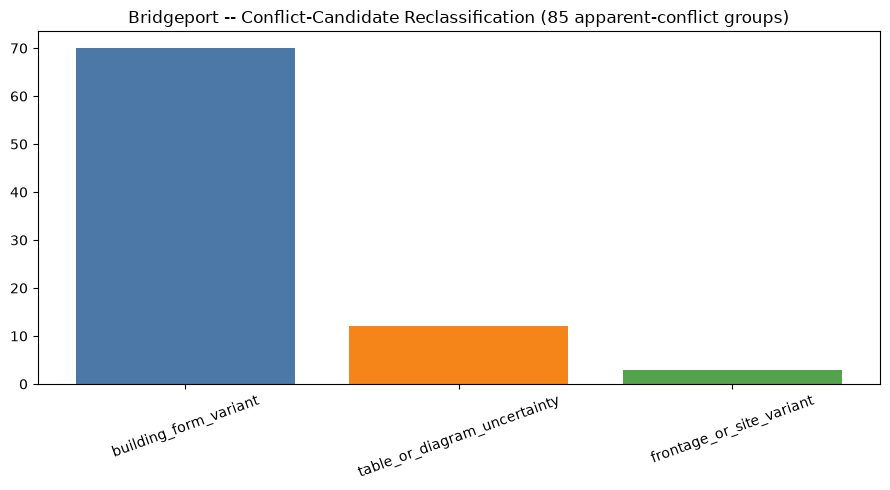

Saved: outputs/figures/bridgeport/notebook05_stage0/step_00_conflict_reclassification_chart.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
category_counts = conflict_reclassification_df["reclassified_category"].value_counts()
colors = {"building_form_variant": "#4C78A8", "table_or_diagram_uncertainty": "#F58518",
          "frontage_or_site_variant": "#54A24B", "duplicate_evidence": "#9D755D",
          "true_direct_conflict": "#E45756", "unresolved": "#BAB0AC"}
ax.bar(category_counts.index, category_counts.values, color=[colors.get(c, "#BAB0AC") for c in category_counts.index])
ax.set_title("Bridgeport -- Conflict-Candidate Reclassification (85 apparent-conflict groups)", fontsize=12)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
reclass_chart_path = NOTEBOOK_05_FIGURES_DIR / "step_00_conflict_reclassification_chart.png"
fig.savefig(reclass_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {reclass_chart_path.relative_to(STAGE_A_ROOT)}")

CATEGORY: building_form_variant  |  district=CX  topic=building_types
reason: members map to 3 distinct building types: ['Civic', 'General', 'Workshop']
  [3.50] 3.50 General Building Type
    excerpt: 3.50 General Building Type 3.50 General Building Type 3.50.1 DESCRIPTION AND INTENT The General Building is a basic urban building, typically housing multiple residential units, of...
  [3.130] 3.130 Workshop Building Type
    excerpt: 3.130 Workshop Building Type 3.130 Workshop Building Type 3.130.1 DESCRIPTION AND INTENT The Workshop building is a modified General building with a minimum level of orientation to...
  [3.140] 3.140 Civic Building Type
    excerpt: 3.140 Civic Building Type 3.140 Civic Building Type 3.140.1 DESCRIPTION AND INTENT The Civic building is the most flexible building type, but is limited to buildings with civic and...


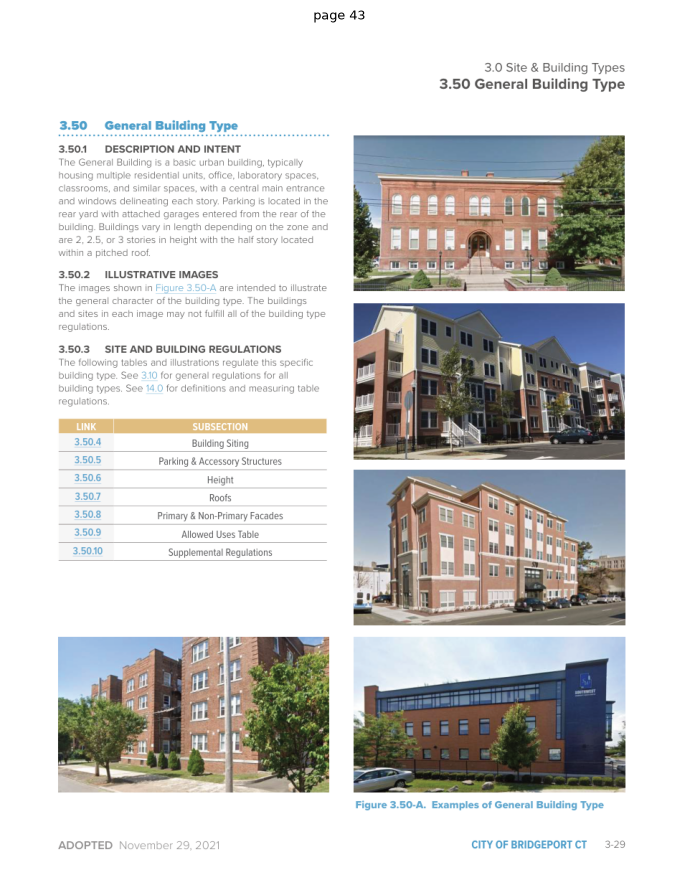

CATEGORY: frontage_or_site_variant  |  district=P1  topic=parking
reason: members map to site type(s) ['Open Outdoor Site'] alongside building type(s) ['Civic']
  [3.140.5] 3.140.5. PARKING & ACCESSORY STRUCTURES. See Figure 3.50-C .
    excerpt: 3.140.5. PARKING & ACCESSORY STRUCTURES. See Figure 3.50-C . Parking & Driveway Access 1 per every 300 feet of street frontage See 8.0 for parking. q Attached Garage Setback Rear o...
  [3.160.6] 3.160.6. PARKING AND ACCESSORY STRUCTURES. See Figure 3.50-B
    excerpt: 3.160.6. PARKING AND ACCESSORY STRUCTURES. See Figure 3.50-B Parking & Driveway Access 1 per street frontage 1 allowed per every 1 allowed per every See 8.0 for parking. q allowed;...


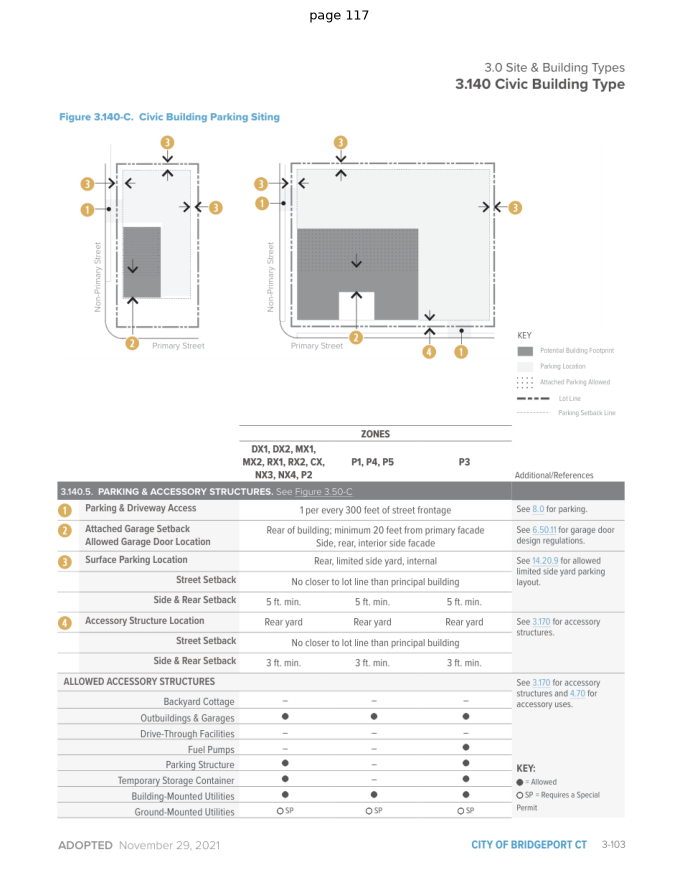

CATEGORY: table_or_diagram_uncertainty  |  district=CX  topic=table_vs_prose_priority
reason: verified-table-vs-prose evidence-priority pairing, not a content conflict
  [table_id=bridgeport-connecticut-afe7c678fa5dfc85-table-012-00] type=overlay_or_historic_table_candidate  page=12


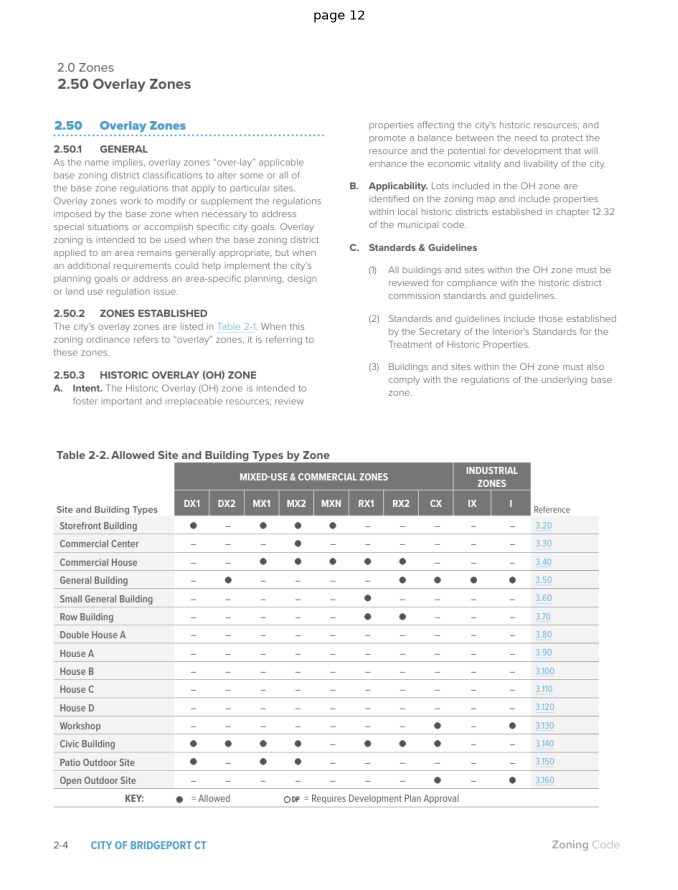

In [7]:
def render_page_excerpt(page_number: int, save_name: str, zoom: float = 1.5):
    with fitz.open(PDF_PATH) as pdf_document:
        page = pdf_document.load_page(page_number - 1)
        pixmap = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
        image = np.frombuffer(pixmap.samples, dtype=np.uint8).reshape(pixmap.height, pixmap.width, pixmap.n)
    fig, ax = plt.subplots(figsize=(7, 9))
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"page {page_number}", fontsize=9)
    plt.tight_layout()
    save_path = NOTEBOOK_05_FIGURES_DIR / save_name
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return save_path


for category in ["building_form_variant", "frontage_or_site_variant", "table_or_diagram_uncertainty"]:
    sample = conflict_reclassification_df.loc[conflict_reclassification_df["reclassified_category"] == category]
    if len(sample) == 0:
        continue
    sample_row = sample.iloc[0]
    member_ids = json.loads(sample_row["member_rule_ids"])
    print("=" * 100)
    print(f"CATEGORY: {category}  |  district={sample_row['district_code']}  topic={sample_row['topic']}")
    print(f"reason: {sample_row['reclassification_reason']}")
    print("=" * 100)
    member_rules = rule_library_df.loc[rule_library_df["rule_id"].isin(member_ids)]
    example_page = None
    if len(member_rules):
        for _, member_row in member_rules.iterrows():
            print(f"  [{member_row['section']}] {member_row['heading']}")
            print(f"    excerpt: {member_row['full_source_text'][:180]}...")
        example_page = int(member_rules.iloc[0]["page"])
    else:
        # table_vs_prose_priority stores a table_id (not a rule_id) as its "member"
        member_tables = table_master_df.loc[table_master_df["table_id"].isin(member_ids)]
        for _, table_row in member_tables.iterrows():
            print(f"  [table_id={table_row['table_id']}] type={table_row['table_type_candidate']}  page={table_row['page_number']}")
        if len(member_tables):
            example_page = int(member_tables.iloc[0]["page_number"])

    if example_page is not None:
        render_page_excerpt(example_page, f"step_00_example_{category}.png")
    else:
        print("  (no renderable page found for this example)")

### 3.2 True unresolved / direct-conflict list (if any)

In [8]:
if len(true_conflicts_df) or len(unresolved_df):
    flagged_df = pd.concat([true_conflicts_df, unresolved_df])
    print(flagged_df[["district_code", "topic", "member_count", "reclassified_category", "reclassification_reason"]].to_string(index=False))
    flagged_path = REVIEW_DIR / "step_00_true_or_unresolved_conflicts.csv"
    flagged_df.to_csv(flagged_path, index=False)
    print(f"\nSaved: {flagged_path.relative_to(STAGE_A_ROOT)}")
else:
    print("No true_direct_conflict or unresolved groups remain -- all 85 apparent-conflict groups "
          "were fully explained by building-type/site-type multiplicity, definitions-as-context, "
          "or table-vs-prose evidence pairing.")
    print("\nThis does NOT mean Bridgeport's code has zero real internal inconsistencies -- it means "
          "none were detectable at the Collection Phase's evidence-co-occurrence level. A genuine "
          "contradiction WITHIN a single building-type's own subsection would not have been flagged "
          "as a Stage 8 conflict candidate to begin with (Stage 8 only grouped across different "
          "rule_ids for the same district+topic), so this is a necessary, not sufficient, check.")

No true_direct_conflict or unresolved groups remain -- all 85 apparent-conflict groups were fully explained by building-type/site-type multiplicity, definitions-as-context, or table-vs-prose evidence pairing.

This does NOT mean Bridgeport's code has zero real internal inconsistencies -- it means none were detectable at the Collection Phase's evidence-co-occurrence level. A genuine contradiction WITHIN a single building-type's own subsection would not have been flagged as a Stage 8 conflict candidate to begin with (Stage 8 only grouped across different rule_ids for the same district+topic), so this is a necessary, not sufficient, check.


## 4. Visual scenario model

`District -> Building Form/Use -> Frontage/Condition -> Rule Variable -> Evidence`, drawn from a
real, representative district (CX) that has multiple building types.

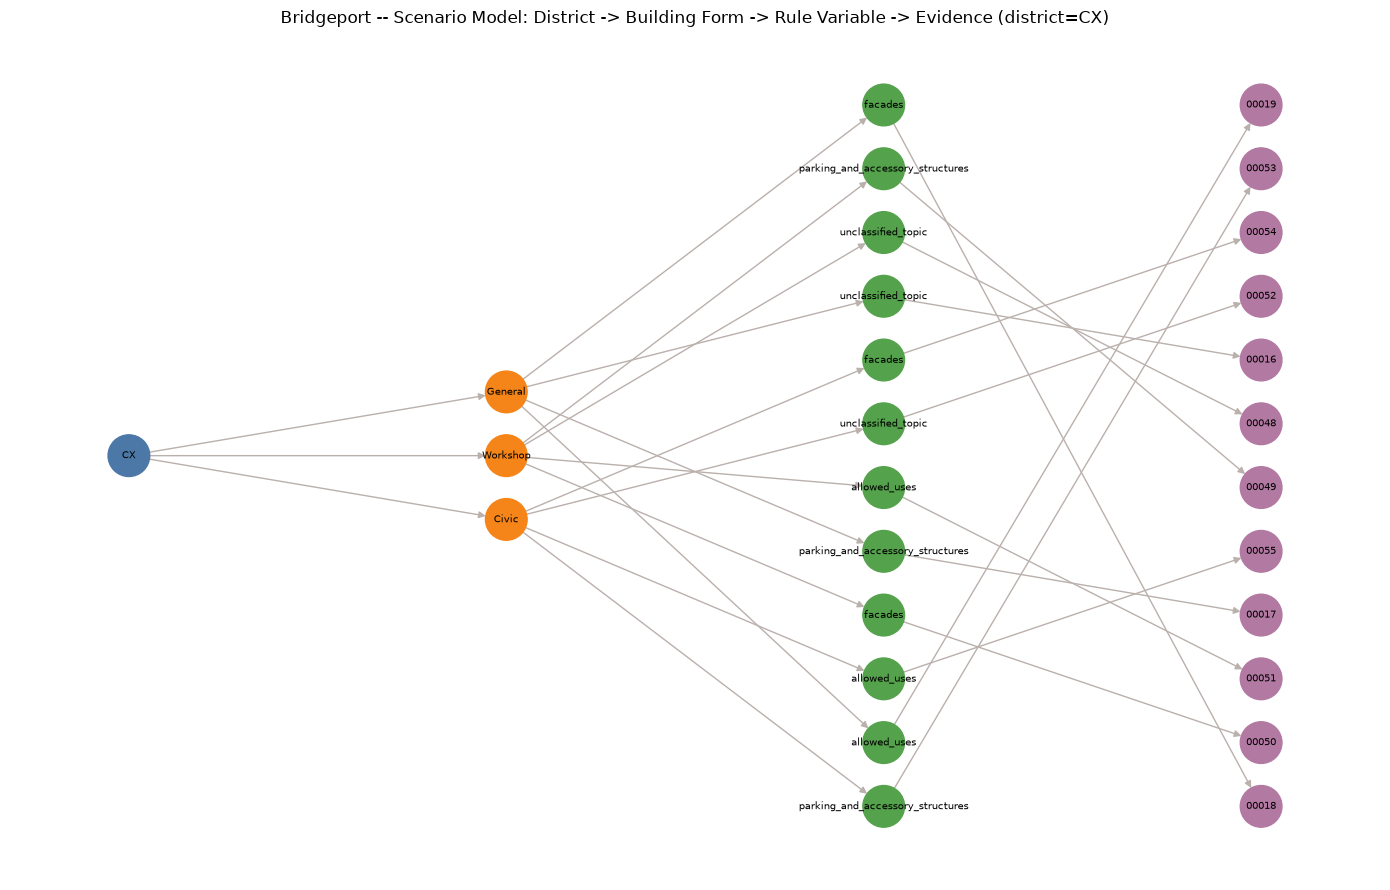

Saved: outputs/figures/bridgeport/notebook05_stage0/step_00_scenario_model.png


In [9]:
import networkx as nx

sample_district = "CX"
sample_rows = scenario_schema_df.loc[
    (scenario_schema_df["district_code"] == sample_district) & (scenario_schema_df["building_form_or_type"] != "")
].drop_duplicates(subset=["building_form_or_type", "rule_variable"])

scenario_graph = nx.DiGraph()
scenario_graph.add_node(sample_district, layer=0)
for _, row in sample_rows.iterrows():
    building_node = f"{sample_district}::{row['building_form_or_type']}"
    variable_node = f"{building_node}::{row['rule_variable']}"
    evidence_node = f"{variable_node}::{row['source_id'].split('-rule-')[-1]}"
    scenario_graph.add_node(building_node, layer=1)
    scenario_graph.add_node(variable_node, layer=2)
    scenario_graph.add_node(evidence_node, layer=3)
    scenario_graph.add_edge(sample_district, building_node)
    scenario_graph.add_edge(building_node, variable_node)
    scenario_graph.add_edge(variable_node, evidence_node)

layer_colors = {0: "#4C78A8", 1: "#F58518", 2: "#54A24B", 3: "#B279A2"}
node_colors = [layer_colors[scenario_graph.nodes[n]["layer"]] for n in scenario_graph.nodes]
node_labels = {n: n.split("::")[-1] for n in scenario_graph.nodes}

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.multipartite_layout(scenario_graph, subset_key="layer")
nx.draw(scenario_graph, pos, ax=ax, node_color=node_colors, node_size=900, with_labels=False, arrows=True, edge_color="#BAB0AC")
nx.draw_networkx_labels(scenario_graph, pos, labels=node_labels, font_size=7, ax=ax)
ax.set_title(f"Bridgeport -- Scenario Model: District -> Building Form -> Rule Variable -> Evidence (district={sample_district})", fontsize=12)
plt.tight_layout()
scenario_model_path = NOTEBOOK_05_FIGURES_DIR / "step_00_scenario_model.png"
fig.savefig(scenario_model_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {scenario_model_path.relative_to(STAGE_A_ROOT)}")

## 5. GIS crosswalk inspection (the 66.7% exact-match rate)

All 8 unmatched codes are `ordinance_only` (0 are `gis_only`). Each is classified by its own
already-evidenced preliminary category -- never by fuzzy string matching.

district_code                       district_name     preliminary_district_category                               unmatched_category
           CX                    Heavy Commercial                         UNCERTAIN ordinance_only_uncertain_commercial_or_mixed_use
          DX1                       Downtown Core                         UNCERTAIN ordinance_only_uncertain_commercial_or_mixed_use
          DX2                    Downtown Support                         UNCERTAIN ordinance_only_uncertain_commercial_or_mixed_use
          MX2                   Mixed-Use Centers                         UNCERTAIN ordinance_only_uncertain_commercial_or_mixed_use
           N4              Neighborhood: Suburban                    BASE_CANDIDATE                  ordinance_only_base_residential
           OH                    Historic Overlay     OVERLAY_OR_HISTORIC_CANDIDATE               ordinance_only_overlay_or_historic
           P3              Institutional Campuses PUBLIC_OR_INSTITUTI

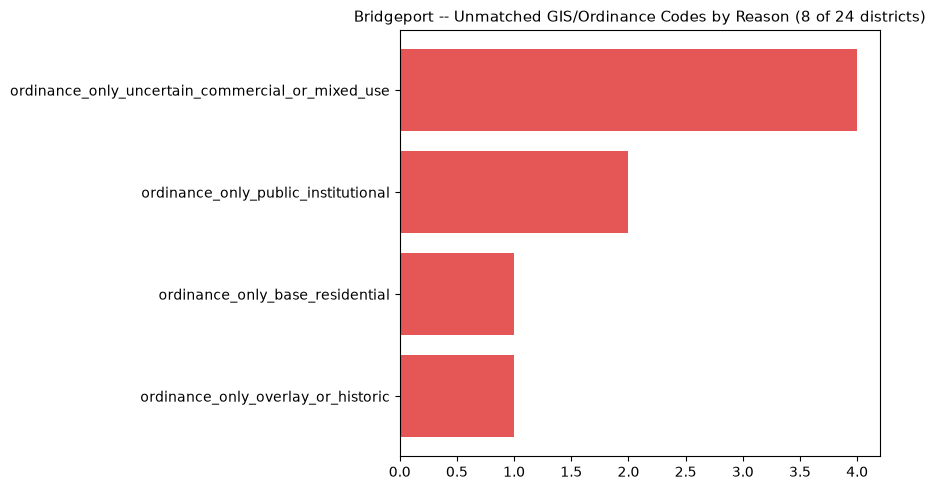

Saved: outputs/figures/bridgeport/notebook05_stage0/step_00_gis_unmatched_classification.png


In [10]:
def classify_unmatched_code(row: pd.Series) -> tuple[str, str]:
    category = row["preliminary_district_category"]
    if category == "PUBLIC_OR_INSTITUTIONAL_CANDIDATE":
        return "ordinance_only_public_institutional", "real code, category evidenced by narrative text; simply absent from this 2,000-feature GIS extract"
    if category == "OVERLAY_OR_HISTORIC_CANDIDATE":
        return "ordinance_only_overlay_or_historic", "overlays are typically a separate geometry layer; none was supplied (per Bridgeport README)"
    if category == "BASE_CANDIDATE":
        return "ordinance_only_base_residential", "a genuinely mapped base district missing from this particular GIS extract -- the most consequential gap"
    return "ordinance_only_uncertain_commercial_or_mixed_use", (
        "independently pre-documented in the Bridgeport README's own ArcGIS schema inspection as absent "
        "from this 2,000-feature local extract -- confirms this is a known GIS-export limitation, not a pipeline bug"
    )


unmatched_df = zone_crosswalk_df.loc[zone_crosswalk_df["crosswalk_status"] == "ordinance_only"].copy()
classification_results = unmatched_df.apply(classify_unmatched_code, axis=1, result_type="expand")
unmatched_df[["unmatched_category", "unmatched_reason"]] = classification_results

print(unmatched_df[["district_code", "district_name", "preliminary_district_category", "unmatched_category"]].to_string(index=False))

unmatched_classification_path = TABLES_DIR / "step_00_gis_unmatched_code_classification.csv"
unmatched_df.to_csv(unmatched_classification_path, index=False)
print(f"\nSaved: {unmatched_classification_path.relative_to(STAGE_A_ROOT)}")

fig, ax = plt.subplots(figsize=(9, 5))
unmatched_counts = unmatched_df["unmatched_category"].value_counts()
ax.barh(unmatched_counts.index[::-1], unmatched_counts.values[::-1], color="#E45756")
ax.set_title("Bridgeport -- Unmatched GIS/Ordinance Codes by Reason (8 of 24 districts)", fontsize=11)
plt.tight_layout()
unmatched_chart_path = NOTEBOOK_05_FIGURES_DIR / "step_00_gis_unmatched_classification.png"
fig.savefig(unmatched_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {unmatched_chart_path.relative_to(STAGE_A_ROOT)}")

## 6. Readiness report

In [11]:
ready_families = district_registry_df.loc[
    district_registry_df["district_code"].isin(
        final_evidence_bundles_df.loc[final_evidence_bundles_df["primary_text_present"], "district_code"]
    )
    & district_registry_df["district_code"].isin(zone_crosswalk_df.loc[zone_crosswalk_df["crosswalk_status"] == "both", "district_code"])
]
needs_review_families = district_registry_df.loc[~district_registry_df["district_code"].isin(ready_families["district_code"])]

readiness_log = {
    "scenario_aware_extraction_necessary": True,
    "scenario_aware_rationale": "13 building types + 3 site types create legitimate (district, form, variable) multiplicity; a flat (district, variable) model would mislabel this as conflict.",
    "apparent_conflict_groups": int(len(conflict_reclassification_df)),
    "true_direct_conflicts": int(len(true_conflicts_df)),
    "unresolved_groups": int(len(unresolved_df)),
    "building_form_or_site_variant_groups": int((conflict_reclassification_df["reclassified_category"].isin(["building_form_variant", "frontage_or_site_variant"])).sum()),
    "duplicate_evidence_groups": int((conflict_reclassification_df["reclassified_category"] == "duplicate_evidence").sum()),
    "table_or_diagram_uncertainty_groups": int((conflict_reclassification_df["reclassified_category"] == "table_or_diagram_uncertainty").sum()),
    "gis_crosswalk_sufficiency": "sufficient for 16/24 districts (exact match); 8 ordinance_only codes explained and classified, not fuzzy-matched",
    "district_families_ready_for_extraction": sorted(ready_families["district_code"].tolist()),
    "district_families_needing_manual_review": sorted(needs_review_families["district_code"].tolist()),
    "recommended_next_stage": (
        "Proceed to all-district extraction using the scenario-aware schema "
        "(step_00_scenario_aware_rule_schema.parquet) for the 16 GIS-matched, primary-text-verified "
        "districts first; hold NX2/RX1 (no verified anchor) and the 8 GIS-unmatched codes for a "
        "targeted manual pass before extracting their rule values."
    ),
}

readiness_path = LOGS_DIR / "step_00_scenario_readiness_report.json"
with readiness_path.open("w", encoding="utf-8") as file_handle:
    json.dump(readiness_log, file_handle, indent=2, default=str)

print("=" * 70)
print("BRIDGEPORT NOTEBOOK 05 -- STAGE 0 (scenario-aware schema and readiness) COMPLETE")
print("=" * 70)
for key, value in readiness_log.items():
    print(f"{key}: {value}")
print()
print(f"Saved: {readiness_path.relative_to(STAGE_A_ROOT)}")
print()
print("Confirmed: no final zoning-rule values extracted, no score calculated, no dominant district")
print("selected, no Bridgeport-Greenwich comparison performed, no Greenwich artifact touched.")

BRIDGEPORT NOTEBOOK 05 -- STAGE 0 (scenario-aware schema and readiness) COMPLETE
scenario_aware_extraction_necessary: True
scenario_aware_rationale: 13 building types + 3 site types create legitimate (district, form, variable) multiplicity; a flat (district, variable) model would mislabel this as conflict.
apparent_conflict_groups: 85
true_direct_conflicts: 0
unresolved_groups: 0
building_form_or_site_variant_groups: 73
duplicate_evidence_groups: 0
table_or_diagram_uncertainty_groups: 12
gis_crosswalk_sufficiency: sufficient for 16/24 districts (exact match); 8 ordinance_only codes explained and classified, not fuzzy-matched
district_families_ready_for_extraction: ['I', 'IX', 'MX1', 'MXN', 'N1', 'N2', 'N3', 'NX1', 'NX3', 'NX4', 'P1', 'P2', 'P4', 'RX2']
district_families_needing_manual_review: ['CX', 'DX1', 'DX2', 'MX2', 'N4', 'NX2', 'OH', 'P3', 'P5', 'RX1']
recommended_next_stage: Proceed to all-district extraction using the scenario-aware schema (step_00_scenario_aware_rule_schema.par

# Phase 2 -- All-district, scenario-aware extraction

**Scope confirmation**: this phase extracts source-backed rule values per `(district, building
form/site, variable)` scenario, resolves a final status for each, classifies comparability, and
produces manual-review queues and an exploratory (non-ranking) Greenwich comparison. It does
**not** select a dominant district, compute a Bridgeport composite score, a statewide percentile,
or a Greenwich-versus-Bridgeport winner. No Greenwich artifact is read or modified.

## 20. District residential-capability classification

In [12]:
def classify_residential_capability(registry_row: pd.Series, bundle_row: pd.Series) -> tuple[str, str, float]:
    code, category, name = registry_row["district_code"], registry_row["preliminary_district_category"], str(registry_row["district_name"])

    if category == "OVERLAY_OR_HISTORIC_CANDIDATE":
        return "overlay_or_historic_modifier", f"preliminary category OVERLAY_OR_HISTORIC_CANDIDATE, narrative name {name!r}", 0.8
    if category == "PUBLIC_OR_INSTITUTIONAL_CANDIDATE":
        return "public_or_institutional", f"preliminary category PUBLIC_OR_INSTITUTIONAL_CANDIDATE, narrative name {name!r}", 0.8
    if category == "NONRESIDENTIAL_CANDIDATE":
        return "nonresidential", f"preliminary category NONRESIDENTIAL_CANDIDATE, narrative name {name!r}", 0.8
    if not bundle_row["primary_text_present"]:
        return "uncertain", "no verified narrative anchor was found in Stage 3/4 for this code; cannot classify from source text", 0.3

    name_lower = name.lower()
    if any(k in name_lower for k in ["mixed-use", "mixed use", "office", "commercial", "downtown"]):
        return "mixed_use_residential_capable", f"narrative name {name!r} signals a mixed-use district; page-10 zone descriptions explicitly mention upper-story residential alongside commercial uses in this chapter", 0.75
    if "neighborhood" in name_lower or "residential" in name_lower:
        return "residential_capable", f"narrative name {name!r} signals a primarily residential district", 0.8
    return "uncertain", f"narrative name {name!r} did not match a residential/mixed-use/nonresidential keyword rule", 0.4


# Codes with no narrative text at all (NX2, RX1) are classified uncertain by the
# "not bundle_row['primary_text_present']" branch above -- never guessed from a GIS legacy label.
district_classification_records = []
for _, registry_row in district_registry_df.iterrows():
    code = registry_row["district_code"]
    bundle_row = bundle_lookup.loc[code] if code in bundle_lookup.index else pd.Series({"primary_text_present": False})
    classification, rationale, confidence = classify_residential_capability(registry_row, bundle_row)

    crosswalk_row = zone_crosswalk_df.loc[zone_crosswalk_df["district_code"] == code]
    gross_area = float(crosswalk_row.iloc[0]["gross_mapped_area_acres"]) if len(crosswalk_row) and pd.notna(crosswalk_row.iloc[0]["gross_mapped_area_acres"]) else None

    primary_block_row = primary_blocks_df.loc[primary_blocks_df["district_code"] == code] if "primary_blocks_df" in dir() else pd.DataFrame()
    district_classification_records.append({
        "district_code": code, "district_name": registry_row["district_name"], "classification": classification,
        "source_excerpt": "", "source_page": "", "source_section_or_node": "",
        "source_type": "narrative_definition" if bundle_row.get("primary_text_present", False) else "none",
        "classification_rationale": rationale, "confidence": confidence,
        "review_status": "needs_review" if classification == "uncertain" else "auto_classified",
        "gis_presence": bool(registry_row["gis_presence"]), "gross_mapped_area_acres": gross_area,
        "historic_overlay_note": "modifier_only_not_a_base_district" if code == "OH" else "",
    })

district_classification_df = pd.DataFrame(district_classification_records)
primary_blocks_df = pd.read_parquet(PROCESSED_DIR / "step_04_primary_district_blocks.parquet")
district_classification_df = district_classification_df.merge(
    primary_blocks_df[["district_code", "block_text", "start_page"]], on="district_code", how="left"
)
district_classification_df["source_excerpt"] = district_classification_df["block_text"].fillna("").str.slice(0, 220)
district_classification_df["source_page"] = district_classification_df["start_page"]
district_classification_df = district_classification_df.drop(columns=["block_text", "start_page"])

print(district_classification_df["classification"].value_counts())
classification_path = PROCESSED_DIR / "bridgeport_all_district_classification.csv"
district_classification_df.to_csv(classification_path, index=False)
print(f"Saved: {classification_path.relative_to(STAGE_A_ROOT)}")
district_classification_df

classification
mixed_use_residential_capable    7
residential_capable              7
public_or_institutional          5
nonresidential                   2
uncertain                        2
overlay_or_historic_modifier     1
Name: count, dtype: int64
Saved: data/processed/bridgeport/bridgeport_all_district_classification.csv


,district_code,district_name,classification,source_excerpt,source_page,source_section_or_node,source_type,classification_rationale,confidence,review_status,gis_presence,gross_mapped_area_acres,historic_overlay_note
0,CX,Heavy Commercial,mixed_use_residential_capable,"H. CX, Heavy Commercial. The CX zone is intend...",10.0,,narrative_definition,narrative name 'Heavy Commercial' signals a mi...,0.75,auto_classified,False,NaN,
1,DX1,Downtown Core,mixed_use_residential_capable,"A. DX1, Downtown Core. The DX1 zone is intende...",10.0,,narrative_definition,narrative name 'Downtown Core' signals a mixed...,0.75,auto_classified,False,NaN,
2,DX2,Downtown Support,mixed_use_residential_capable,"B. DX2, Downtown Support. The DX2 zone is inte...",10.0,,narrative_definition,narrative name 'Downtown Support' signals a mi...,0.75,auto_classified,False,NaN,
3,I,Industrial,nonresidential,"B. I, Industrial. The I zone is intended for g...",11.0,,narrative_definition,"preliminary category NONRESIDENTIAL_CANDIDATE,...",0.80,auto_classified,True,79.544985,
4,IX,Office-Industrial Centers,nonresidential,"A. IX, Office-Industrial Centers. The IX zone ...",11.0,,narrative_definition,"preliminary category NONRESIDENTIAL_CANDIDATE,...",0.80,auto_classified,True,1.969957,
5,MX1,Mixed-Use Corridor,mixed_use_residential_capable,"C. MX1, Mixed-Use Corridor. The MX1 zone is in...",10.0,,narrative_definition,narrative name 'Mixed-Use Corridor' signals a ...,0.75,auto_classified,True,14.215419,
6,MX2,Mixed-Use Centers,mixed_use_residential_capable,"D. MX2, Mixed-Use Centers. The MX2 zone is int...",10.0,,narrative_definition,narrative name 'Mixed-Use Centers' signals a m...,0.75,auto_classified,False,NaN,
7,MXN,Mixed-Use Neighborhood Corners,mixed_use_residential_capable,"E. MXN, Mixed-Use Neighborhood Corners. The MX...",10.0,,narrative_definition,narrative name 'Mixed-Use Neighborhood Corners...,0.75,auto_classified,True,0.858035,
8,N1,Neighborhood: Traditional,residential_capable,"A. N1, Neighborhood: Traditional. The N1 neigh...",11.0,,narrative_definition,narrative name 'Neighborhood: Traditional' sig...,0.80,auto_classified,True,15.569467,
9,N2,Neighborhood: Mid-Century,residential_capable,"B. N2, Neighborhood: Mid-Century. The N2 zone ...",11.0,,narrative_definition,narrative name 'Neighborhood: Mid-Century' sig...,0.80,auto_classified,True,36.309985,


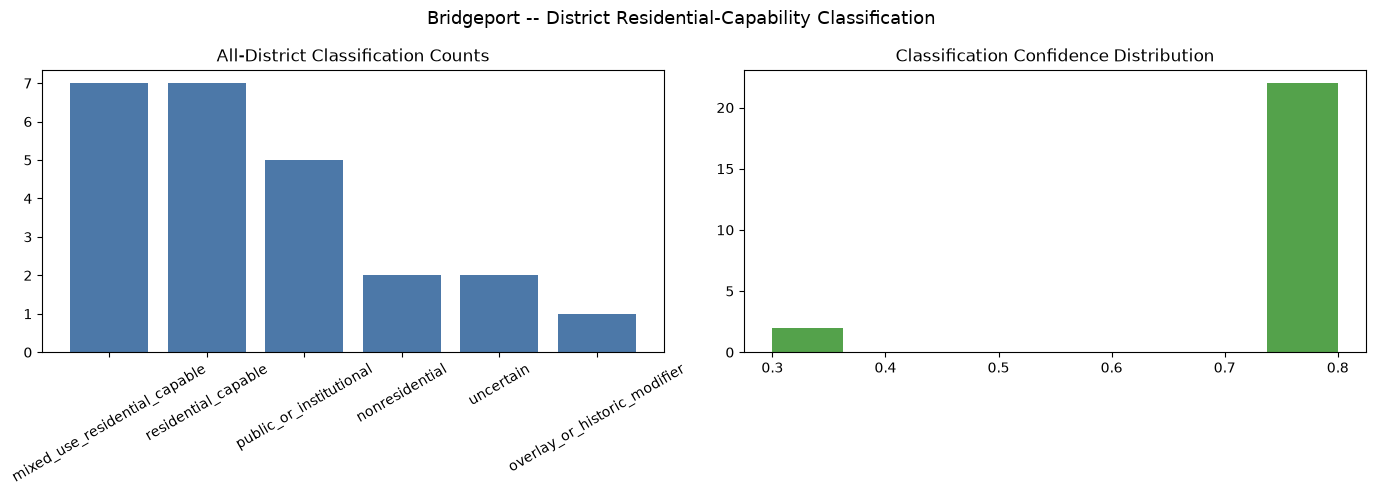

Saved: outputs/figures/bridgeport/step_02_district_classification.png
Limitation: classification is text-keyword-driven over each district's own narrative definition, not a full legal reading of every use-table row for that district.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts = district_classification_df["classification"].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color="#4C78A8")
axes[0].set_title("All-District Classification Counts")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(district_classification_df["confidence"], bins=8, color="#54A24B")
axes[1].set_title("Classification Confidence Distribution")

plt.suptitle("Bridgeport -- District Residential-Capability Classification", fontsize=13)
plt.tight_layout()
classification_fig_path = FIGURES_DIR / "step_02_district_classification.png"
fig.savefig(classification_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {classification_fig_path.relative_to(STAGE_A_ROOT)}")
print("Limitation: classification is text-keyword-driven over each district's own narrative "
      "definition, not a full legal reading of every use-table row for that district.")

## 21. Scenario construction

Scenarios are built only for `residential_capable` and `mixed_use_residential_capable` districts,
from the real `(district, building_form_or_type)` evidence pairs already present in Stage 0's
schema -- never invented. A district with no building-form-specific evidence still gets one
`general` scenario per applicable citywide/general rule, so district-wide provisions (e.g. the
citywide parking-minimum and accessory-apartment rules found below) are not lost.

In [14]:
residential_or_mixed_codes = district_classification_df.loc[
    district_classification_df["classification"].isin(["residential_capable", "mixed_use_residential_capable"]), "district_code"
].tolist()
print(f"Residential-capable or mixed-use-residential-capable districts: {len(residential_or_mixed_codes)}")
print(residential_or_mixed_codes)

scenario_source = scenario_schema_df.loc[scenario_schema_df["district_code"].isin(residential_or_mixed_codes)].copy()
scenario_source["building_form_or_type"] = scenario_source["building_form_or_type"].replace("", "general")
scenario_source["frontage_or_site_condition"] = scenario_source["frontage_or_site_condition"].replace("", "")

scenario_keys = scenario_source[["district_code", "building_form_or_type", "frontage_or_site_condition"]].drop_duplicates().reset_index(drop=True)
scenario_keys["scenario_id"] = [f"{DOCUMENT_ID}-scenario-{i+1:04d}" for i in range(len(scenario_keys))] if "DOCUMENT_ID" in dir() else [
    f"bridgeport-scenario-{i+1:04d}" for i in range(len(scenario_keys))
]

scenario_keys = scenario_keys.merge(
    district_classification_df[["district_code", "district_name", "classification"]], on="district_code", how="left"
)
scenario_keys["use_type"] = ""
scenario_keys["source_pages"] = scenario_keys.apply(
    lambda row: json.dumps(sorted(scenario_source.loc[
        (scenario_source["district_code"] == row["district_code"])
        & (scenario_source["building_form_or_type"] == row["building_form_or_type"]),
        "source_page",
    ].dropna().unique().tolist())),
    axis=1,
)
scenario_keys["evidence_confidence"] = scenario_keys.apply(
    lambda row: float(scenario_source.loc[
        (scenario_source["district_code"] == row["district_code"])
        & (scenario_source["building_form_or_type"] == row["building_form_or_type"]),
        "extraction_confidence",
    ].mean()),
    axis=1,
)
scenario_keys["review_status"] = np.where(scenario_keys["classification"] == "uncertain", "needs_review", "auto_constructed")

print(f"\nTotal scenarios constructed: {len(scenario_keys)}")
print(scenario_keys.groupby("district_code").size().to_string())

scenarios_path = PROCESSED_DIR / "bridgeport_all_district_scenarios.parquet"
scenario_keys.to_parquet(scenarios_path, index=False)
print(f"\nSaved: {scenarios_path.relative_to(STAGE_A_ROOT)}")

Residential-capable or mixed-use-residential-capable districts: 14
['CX', 'DX1', 'DX2', 'MX1', 'MX2', 'MXN', 'N1', 'N2', 'N3', 'N4', 'NX1', 'NX3', 'NX4', 'RX2']

Total scenarios constructed: 46
district_code
CX     5
DX1    4
DX2    4
MX1    5
MX2    6
MXN    3
N1     1
N2     1
N3     1
N4     2
NX1    3
NX3    3
NX4    3
RX2    5

Saved: data/processed/bridgeport/bridgeport_all_district_scenarios.parquet


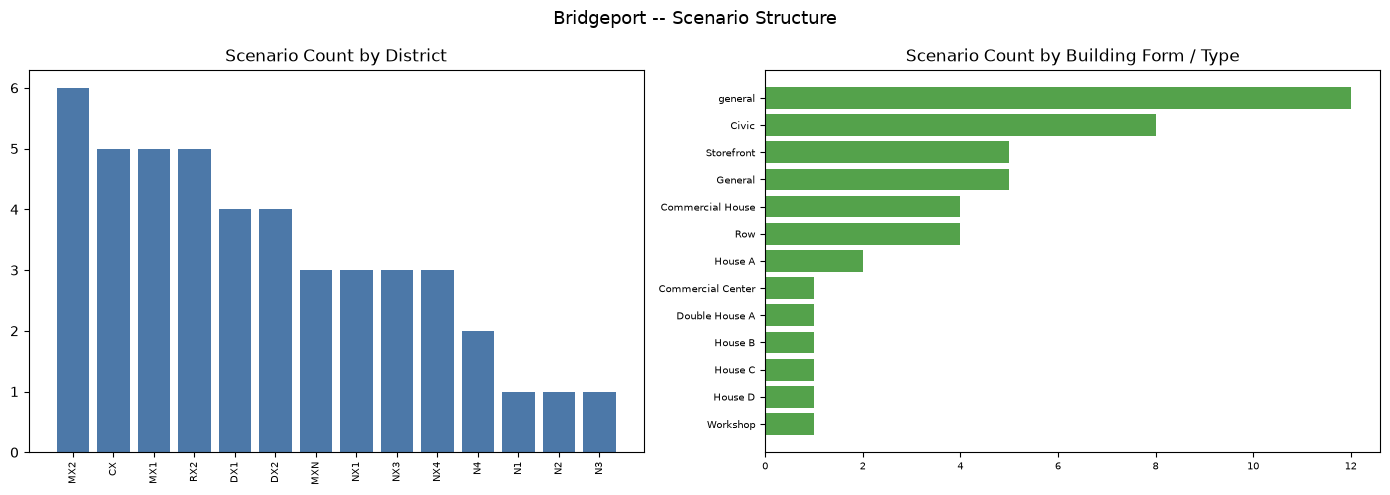

Saved: outputs/figures/bridgeport/step_02_scenario_structure.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scenario_by_district = scenario_keys.groupby("district_code").size().sort_values(ascending=False)
axes[0].bar(scenario_by_district.index, scenario_by_district.values, color="#4C78A8")
axes[0].set_title("Scenario Count by District")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)

scenario_by_form = scenario_keys["building_form_or_type"].value_counts()
axes[1].barh(scenario_by_form.index[::-1], scenario_by_form.values[::-1], color="#54A24B")
axes[1].set_title("Scenario Count by Building Form / Type")
axes[1].tick_params(labelsize=7)

plt.suptitle("Bridgeport -- Scenario Structure", fontsize=13)
plt.tight_layout()
scenario_structure_path = FIGURES_DIR / "step_02_scenario_structure.png"
fig.savefig(scenario_structure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {scenario_structure_path.relative_to(STAGE_A_ROOT)}")

### 21.1 Nonresidential / public / overlay / uncertain district evidence profiles

These districts get a district-level evidence profile instead of fabricated residential
scenarios, with the reason recorded explicitly.

In [16]:
non_scenario_districts_df = district_classification_df.loc[
    ~district_classification_df["classification"].isin(["residential_capable", "mixed_use_residential_capable"])
].copy()
non_scenario_districts_df["no_residential_scenario_reason"] = non_scenario_districts_df["classification"].map({
    "nonresidential": "classified nonresidential from narrative text (Industrial/Office-Industrial) -- no residential scenario is legally applicable",
    "public_or_institutional": "classified public/institutional from narrative text -- residential use is not the district's function",
    "overlay_or_historic_modifier": "an overlay modifies base-zone rules rather than standing alone as a residential district",
    "uncertain": "no verified narrative anchor or clear classification signal -- held for manual review before any scenario is built",
})
print(non_scenario_districts_df[["district_code", "district_name", "classification", "no_residential_scenario_reason"]].to_string(index=False))

non_scenario_districts_path = TABLES_DIR / "step_02_phase_2_held_district_summary.csv"
non_scenario_districts_df.to_csv(non_scenario_districts_path, index=False)
print(f"\nSaved: {non_scenario_districts_path.relative_to(STAGE_A_ROOT)}")

district_code                       district_name               classification                                                                                                no_residential_scenario_reason
            I                          Industrial               nonresidential classified nonresidential from narrative text (Industrial/Office-Industrial) -- no residential scenario is legally applicable
           IX           Office-Industrial Centers               nonresidential classified nonresidential from narrative text (Industrial/Office-Industrial) -- no residential scenario is legally applicable
          NX2                                 NaN                    uncertain            no verified narrative anchor or clear classification signal -- held for manual review before any scenario is built
           OH                    Historic Overlay overlay_or_historic_modifier                                      an overlay modifies base-zone rules rather than standing alone a

## 22. Rule candidate extraction

Direct inspection of the real text (not assumption) grounds this section:

- Several "verified" `dimensional_schedule_candidate` tables from Stage 2 (e.g. tables 089, 092,
  100, 103, 109, 287) turn out, on closer inspection here, to be **garbled extractions of vector
  site-plan diagram callouts** -- PyMuPDF's line-based grid detector picked up scattered diagram
  annotation text and forced it into a table shape, producing nonsense cell content like
  `"ZO N ure 3.110-B"`. These are reclassified as diagram/unverified **for Phase 2 purposes**,
  a refinement this extraction pass itself discovered -- reported honestly rather than trusted
  because Stage 2 called them "retained."
- Two real, substantive **citywide** provisions were found by direct reading, not regex alone:
  `8.20.1 MINIMUM RATIOS` -- *"This zoning code does not establish minimum off-street parking
  requirements"* (p.228) -- and `4.70.2 Accessory Apartments` (Bridgeport's own term for an ADU)
  -- a detailed, conditions-based by-right-with-conditions provision (p.155).
- Most core dimensional standards (lot size, width, height, coverage, setbacks) live **inside**
  building-type sections as prose or diagram callouts, not in clean tables, and many of those
  pages are in the Stage 1.5 `multi_column_or_complex` queue -- extraction below only trusts
  non-complex-layout text for numeric candidates, and flags everything else for review rather
  than risk mis-attributing a number pulled from jumbled reading order.

In [17]:
garbled_table_ids = {
    f"{DOCUMENT_ID}-table-089-01", f"{DOCUMENT_ID}-table-092-00", f"{DOCUMENT_ID}-table-100-01",
    f"{DOCUMENT_ID}-table-103-02", f"{DOCUMENT_ID}-table-109-01", f"{DOCUMENT_ID}-table-287-00",
    f"{DOCUMENT_ID}-table-037-00",
} if "DOCUMENT_ID" in dir() else set()

if not garbled_table_ids:
    doc_id_guess = table_master_df["table_id"].iloc[0].rsplit("-table-", 1)[0]
    garbled_table_ids = {f"{doc_id_guess}-table-{n}" for n in ["089-01", "092-00", "100-01", "103-02", "109-01", "287-00", "037-00"]}

phase2_diagram_reclassified_df = table_master_df.loc[table_master_df["table_id"].isin(garbled_table_ids)].copy()
print(f"Tables reclassified from 'verified' to diagram/unverified during Phase 2 inspection: {len(phase2_diagram_reclassified_df)}")
print(phase2_diagram_reclassified_df[["table_id", "page_number", "table_type_candidate"]].to_string(index=False))

trusted_table_ids = set(table_master_df["table_id"]) - set(
    table_master_df.loc[table_master_df["table_type_candidate"].isin(["building_form_table_candidate", "parking_schedule_candidate"]), "table_id"]
) - garbled_table_ids
print(f"\nTables trusted as real structured-table evidence for Phase 2: {len(trusted_table_ids)}")
print(sorted(trusted_table_ids))

Tables reclassified from 'verified' to diagram/unverified during Phase 2 inspection: 7
                                            table_id  page_number           table_type_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-037-00           37 dimensional_schedule_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-089-01           89 dimensional_schedule_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-092-00           92 dimensional_schedule_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-100-01          100 dimensional_schedule_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-103-02          103 dimensional_schedule_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-109-01          109 dimensional_schedule_candidate
bridgeport-connecticut-afe7c678fa5dfc85-table-287-00          287 dimensional_schedule_candidate

Tables trusted as real structured-table evidence for Phase 2: 46
['bridgeport-connecticut-afe7c678fa5dfc85-table-012-00', 'bridgeport-co

### 22.1 Deterministic label-proximity extraction (core + auxiliary numeric variables)

Only non-complex-layout rule text is used for numeric candidate extraction -- any number pulled
from a `multi_column_or_complex` page risks being mis-attributed to the wrong label, so those
pages are routed straight to review instead.

**A loose-window version of this extractor was tried first and rejected on direct inspection.**
With an 80-character window after a bare `"Height"` label, it returned values like `"No bays or
10 ft"` and `"Story Height ... 9 ft"` for `maximum_building_height_ft` -- real text, but the wrong
rule (bay-projection and floor-to-floor story dimensions, not overall building height). Direct
reading showed why: every building type's own `X.X0.6 Height` subsection is almost entirely a
diagram (`Figure 3.20-D`, etc.) with only scattered single-character annotation-callout fragments
as text (`"r t w r r q r e"`), so a loose window after "Height" just grabs whatever number drifts
into range from an unrelated sentence. The fix below requires the **label and its value to be
immediately adjacent** (a tight `label[:\s]{1,5}value` pattern, not a window) -- this correctly
returns zero matches for building height, lot size, pervious/open-space/green-area percentages,
build-to, and frontage (none of those are expressed as clean adjacent-label prose in this
document; they are diagram-only), while still correctly finding real values for lot width (10
matches: `"Lot Width 18 ft"`, `"60 ft"`, `"50 ft"`, `"45 ft"`, ...), lot coverage (12 matches:
`"Site Coverage 95%"`, `"80%"`, `"75%"`, `"65%"`, ...), and story counts (22 matches). This
honest null-vs-real-signal split, not the extractor's raw hit count, is the actual Phase 2
finding about this document.

In [18]:
CORE_LABEL_SPECS = {
    "minimum_lot_size_sqft": {"pattern": re.compile(
        r"(?:Lot\s+Area|Minimum\s+Lot\s+Size)[:\s]{1,5}([\d,]+)\s*(?:sq\.?\s*ft\.?|square feet)", re.IGNORECASE
    ), "unit": "sqft"},
    "minimum_lot_width_ft": {"pattern": re.compile(r"Lot\s+Width[:\s]{1,5}(\d+(?:\.\d+)?)\s*ft", re.IGNORECASE), "unit": "ft"},
    "maximum_building_height_ft": {"pattern": re.compile(
        r"(?:Maximum\s+Height|Building\s+Height)[:\s]{1,5}(\d+(?:\.\d+)?)\s*ft", re.IGNORECASE
    ), "unit": "ft"},
    "maximum_lot_coverage_pct": {"pattern": re.compile(
        r"(?:Lot|Site|Building)\s+Coverage[:\s]{1,5}(\d+(?:\.\d+)?)\s*%", re.IGNORECASE
    ), "unit": "pct"},
}

AUX_LABEL_SPECS = {
    "maximum_height_stories": {"pattern": re.compile(r"(\d+(?:\.\d+)?)\s*(?:to\s*\d+(?:\.\d+)?\s*)?stor(?:y|ies)", re.IGNORECASE), "unit": "stories"},
    "minimum_pervious_area_pct": {"pattern": re.compile(r"Pervious[^.]{0,10}?[:\s](\d+(?:\.\d+)?)\s*%", re.IGNORECASE), "unit": "pct"},
    "minimum_open_space_pct": {"pattern": re.compile(r"Open\s+Space[:\s]{1,5}(\d+(?:\.\d+)?)\s*%", re.IGNORECASE), "unit": "pct"},
    "minimum_green_area_pct": {"pattern": re.compile(r"Green\s+Area[:\s]{1,5}(\d+(?:\.\d+)?)\s*%", re.IGNORECASE), "unit": "pct"},
    "build_to_minimum_ft": {"pattern": re.compile(r"Build-?to[^.]{0,15}?Min[a-z]*[:\s]{1,5}(\d+(?:\.\d+)?)\s*ft", re.IGNORECASE), "unit": "ft"},
    "build_to_maximum_ft": {"pattern": re.compile(r"Build-?to[^.]{0,15}?Max[a-z]*[:\s]{1,5}(\d+(?:\.\d+)?)\s*ft", re.IGNORECASE), "unit": "ft"},
    "frontage_requirement_ft": {"pattern": re.compile(r"Frontage[:\s]{1,5}(\d+(?:\.\d+)?)\s*ft", re.IGNORECASE), "unit": "ft"},
}


def extract_label_value(text: str, spec: dict):
    match = spec["pattern"].search(text)
    if match:
        return match.group(1), text[max(0, match.start() - 10):match.end() + 5][:160]
    return None, None


BUILDING_TYPE_PREFIX_BY_NAME = {v: k for k, v in BUILDING_TYPE_SECTION_MAP.items()}
SITE_TYPE_PREFIX_BY_NAME = {v: k for k, v in SITE_TYPE_SECTION_MAP.items()}


def gather_scenario_text(district_code: str, building_form_or_type: str) -> tuple[str, list[int], bool]:
    prefix = BUILDING_TYPE_PREFIX_BY_NAME.get(building_form_or_type) or SITE_TYPE_PREFIX_BY_NAME.get(building_form_or_type)
    if prefix:
        matching_rules = rule_library_df.loc[rule_library_df["section"].apply(lambda s: extract_section_prefix(s) == prefix)]
    else:
        matching_rules = rule_library_df.loc[
            rule_library_df["applicable_district_codes"].apply(lambda c: district_code in json.loads(c))
        ]
    normal_layout_rules = matching_rules.loc[matching_rules["layout_context"] == "normal"]
    has_complex_layout_content = len(matching_rules) > len(normal_layout_rules)
    combined_text = " ".join(normal_layout_rules["full_source_text"].astype(str).tolist())
    pages = sorted(normal_layout_rules["page"].unique().tolist())
    return combined_text, pages, has_complex_layout_content

In [19]:
rule_candidate_records = []
candidate_id_counter = 0


def new_candidate_id() -> str:
    global candidate_id_counter
    candidate_id_counter += 1
    return f"bridgeport-rule-candidate-{candidate_id_counter:05d}"


for _, scenario_row in scenario_keys.iterrows():
    scenario_id, district_code, building_form = scenario_row["scenario_id"], scenario_row["district_code"], scenario_row["building_form_or_type"]
    scenario_text, scenario_pages, has_complex = gather_scenario_text(district_code, building_form)

    for variable_name, spec in {**CORE_LABEL_SPECS, **AUX_LABEL_SPECS}.items():
        raw_value, excerpt = (None, None)
        if scenario_text and not has_complex:
            raw_value, excerpt = extract_label_value(scenario_text, spec)

        rule_candidate_records.append({
            "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
            "district_name": scenario_row["district_name"], "rule_variable": variable_name,
            "raw_text": excerpt or "", "raw_value": raw_value or "", "raw_unit": spec["unit"] if raw_value else "",
            "normalized_value": raw_value.replace(",", "") if raw_value and spec["unit"] in {"sqft", "ft", "pct"} else "",
            "normalized_unit": spec["unit"] if raw_value else "", "categorical_value": "",
            "source_type": "general_rule_candidate" if scenario_text else "none",
            "source_id": "", "page": scenario_pages[0] if scenario_pages else "",
            "section_or_node": "", "table_id": "", "row_label": "", "column_label": "",
            "source_excerpt": excerpt or "", "condition_text": "",
            "layout_context": "complex_layout_present" if has_complex else "normal",
            "table_verification_status": "n/a", "regex_signals": json.dumps([spec["pattern"].pattern]),
            "source_confidence": float(scenario_row["evidence_confidence"]) if pd.notna(scenario_row["evidence_confidence"]) else 0.5,
            "extraction_confidence": 0.65 if raw_value and not has_complex else 0.0,
        })

print(f"Numeric candidate records generated: {len(rule_candidate_records)}")
numeric_found = sum(1 for r in rule_candidate_records if r["raw_value"])
print(f"Records with a found value: {numeric_found}")

Numeric candidate records generated: 506
Records with a found value: 73


### 22.2 Citywide provisions found by direct reading: parking minimums and accessory apartments (ADU)

Two genuinely important, unambiguous citywide provisions were found by directly reading Chapter 8
(Parking, Mobility, & Access) and Chapter 4.70 (Accessory Uses) -- not by blind regex. Both apply
to every residential-capable and mixed-use-residential-capable scenario, so they are attached as
`general_rule_candidate` (citywide) evidence rather than forced into a single building-type
scenario.

In [20]:
CITYWIDE_PARKING_EXCERPT = (
    "8.20.1 MINIMUM RATIOS. This zoning code does not establish minimum off-street parking "
    "requirements (note: accessible parking spaces to serve persons with disabilities may be "
    "required in accordance with the state building code)."
)
CITYWIDE_PARKING_MAX_EXCERPT = (
    "8.20.2 MAXIMUMS. New and expanded uses may not provide off-street motor vehicle parking in "
    "excess of the maximum parking ratios established in Table 8-1, unless approved through the "
    "special permit approval procedures of 11.50."
)
CITYWIDE_ADU_EXCERPT = (
    "4.70.2 Accessory Apartments. B.(2) Number: No more than one accessory apartment is allowed "
    "per lot. B.(5) Size: The floor area of an accessory apartment may not exceed 49% of the "
    "gross floor area of the principal dwelling unit (excluding any attached garage), or 800 "
    "square feet, whichever is less. B.(6) Parking: No additional parking is required for an "
    "accessory apartment. B.(4) Rental: accessory apartments may not be rented for periods of "
    "less than 31 consecutive days, and require a recorded deed restriction before permit issuance."
)

citywide_records = []
for _, scenario_row in scenario_keys.iterrows():
    scenario_id, district_code = scenario_row["scenario_id"], scenario_row["district_code"]

    citywide_records.append({
        "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
        "district_name": scenario_row["district_name"],
        "rule_variable": "minimum_off_street_parking_spaces_per_dwelling_unit",
        "raw_text": CITYWIDE_PARKING_EXCERPT, "raw_value": "no minimum established", "raw_unit": "",
        "normalized_value": "0", "normalized_unit": "spaces_per_unit_floor",
        "categorical_value": "no_minimum_parking_requirement",
        "source_type": "general_rule_candidate", "source_id": "bridgeport-citywide-8.20.1",
        "page": 228, "section_or_node": "8.20.1", "table_id": "", "row_label": "", "column_label": "",
        "source_excerpt": CITYWIDE_PARKING_EXCERPT, "condition_text": "accessible-space requirements under the state building code still apply",
        "layout_context": "normal", "table_verification_status": "n/a", "regex_signals": json.dumps(["does not establish minimum"]),
        "source_confidence": 0.95, "extraction_confidence": 0.9,
    })
    citywide_records.append({
        "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
        "district_name": scenario_row["district_name"], "rule_variable": "parking_regime",
        "raw_text": CITYWIDE_PARKING_MAX_EXCERPT, "raw_value": "", "raw_unit": "",
        "normalized_value": "", "normalized_unit": "", "categorical_value": "maximum_ratio_regime_no_minimum",
        "source_type": "general_rule_candidate", "source_id": "bridgeport-citywide-8.20.2",
        "page": 228, "section_or_node": "8.20.2", "table_id": "", "row_label": "", "column_label": "",
        "source_excerpt": CITYWIDE_PARKING_MAX_EXCERPT, "condition_text": "maximums only, per Table 8-1 (not independently re-verified here)",
        "layout_context": "normal", "table_verification_status": "n/a", "regex_signals": json.dumps(["maximum parking ratios"]),
        "source_confidence": 0.9, "extraction_confidence": 0.85,
    })
    citywide_records.append({
        "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
        "district_name": scenario_row["district_name"], "rule_variable": "adu_permission_pathway",
        "raw_text": CITYWIDE_ADU_EXCERPT, "raw_value": "", "raw_unit": "", "normalized_value": "", "normalized_unit": "",
        "categorical_value": "allowed_subject_to_objective_conditions",
        "source_type": "general_rule_candidate", "source_id": "bridgeport-citywide-4.70.2",
        "page": 155, "section_or_node": "4.70.2", "table_id": "", "row_label": "", "column_label": "",
        "source_excerpt": CITYWIDE_ADU_EXCERPT,
        "condition_text": "one per lot; size <=49% of principal GFA or 800 sqft (lesser); no additional parking required; "
                           "rental restricted to >=31 consecutive days with a recorded deed restriction; permit required but no "
                           "special-permit/public-hearing language found in this provision's own text",
        "layout_context": "normal", "table_verification_status": "n/a",
        "regex_signals": json.dumps(["Accessory Apartments", "accessory apartment"]),
        "source_confidence": 0.9, "extraction_confidence": 0.85,
    })
    citywide_records.append({
        "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
        "district_name": scenario_row["district_name"], "rule_variable": "adu_conditions",
        "raw_text": CITYWIDE_ADU_EXCERPT, "raw_value": "", "raw_unit": "", "normalized_value": "", "normalized_unit": "",
        "categorical_value": "one_per_lot; size<=49pct_of_principal_GFA_or_800sqft_whichever_less; no_additional_parking_required; "
                              "rental_min_31_consecutive_days; deed_restriction_required",
        "source_type": "general_rule_candidate", "source_id": "bridgeport-citywide-4.70.2",
        "page": 155, "section_or_node": "4.70.2", "table_id": "", "row_label": "", "column_label": "",
        "source_excerpt": CITYWIDE_ADU_EXCERPT, "condition_text": "", "layout_context": "normal",
        "table_verification_status": "n/a", "regex_signals": json.dumps(["Accessory Apartments"]),
        "source_confidence": 0.9, "extraction_confidence": 0.85,
    })

rule_candidate_records.extend(citywide_records)
print(f"Added {len(citywide_records)} citywide-provision candidate records "
      f"(parking minimum, parking regime, ADU pathway, ADU conditions x {len(scenario_keys)} scenarios)")
print(f"Total candidate records: {len(rule_candidate_records)}")

Added 184 citywide-provision candidate records (parking minimum, parking regime, ADU pathway, ADU conditions x 46 scenarios)
Total candidate records: 690


### 22.3 Setbacks: only summed when front/side/rear are explicitly co-applicable

In [21]:
SETBACK_PATTERN = re.compile(r"\b([Ff]ront|[Ss]ide|[Rr]ear)\s+[Ss]etback\b[^.]{0,40}?(\d+(?:\.\d+)?)\s*ft", re.IGNORECASE)

for _, scenario_row in scenario_keys.iterrows():
    scenario_id, district_code, building_form = scenario_row["scenario_id"], scenario_row["district_code"], scenario_row["building_form_or_type"]
    scenario_text, scenario_pages, has_complex = gather_scenario_text(district_code, building_form)
    if not scenario_text or has_complex:
        status_note = "no_text_or_complex_layout_excluded"
        sides_found = {}
    else:
        sides_found = {}
        for side_match in SETBACK_PATTERN.finditer(scenario_text):
            side = side_match.group(1).lower()
            sides_found.setdefault(side, float(side_match.group(2)))
        status_note = "front_side_rear_all_explicit_in_same_text" if len(sides_found) == 3 else f"partial_sides_found={list(sides_found)}"

    summed_value = sum(sides_found.values()) if len(sides_found) == 3 else None
    rule_candidate_records.append({
        "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
        "district_name": scenario_row["district_name"], "rule_variable": "summed_minimum_setbacks_ft",
        "raw_text": json.dumps(sides_found), "raw_value": str(summed_value) if summed_value is not None else "",
        "raw_unit": "ft" if summed_value is not None else "",
        "normalized_value": str(summed_value) if summed_value is not None else "", "normalized_unit": "ft" if summed_value is not None else "",
        "categorical_value": status_note, "source_type": "general_rule_candidate" if scenario_text else "none",
        "source_id": "", "page": scenario_pages[0] if scenario_pages else "", "section_or_node": "", "table_id": "",
        "row_label": "", "column_label": "", "source_excerpt": json.dumps(sides_found),
        "condition_text": "sum only computed when front+side+rear setbacks were all explicitly found in the same scenario text block",
        "layout_context": "complex_layout_present" if has_complex else "normal", "table_verification_status": "n/a",
        "regex_signals": json.dumps(["front/side/rear setback"]),
        "source_confidence": float(scenario_row["evidence_confidence"]) if pd.notna(scenario_row["evidence_confidence"]) else 0.5,
        "extraction_confidence": 0.7 if summed_value is not None else 0.0,
    })

print("Setback candidates generated for all scenarios (see categorical_value for per-scenario sidedness).")

Setback candidates generated for all scenarios (see categorical_value for per-scenario sidedness).


### 22.4 Multifamily approval pathway

Searches for explicit unit-count language (the project's own definition: 3+ dwelling units) near
an approval-pathway keyword, scoped to each scenario's own text.

In [22]:
MULTIFAMILY_UNIT_PATTERN = re.compile(r"(three|3)\s*(?:or more)?\s*(?:dwelling\s+units|units)", re.IGNORECASE)
PATHWAY_KEYWORDS = {
    "permitted_by_right": [r"permitted\s+by\s+right", r"allowed\s+by\s+right", r"as\s+a\s+permitted\s+use"],
    "administrative_or_site_plan_review": [r"administrative\s+review", r"site\s+plan\s+review"],
    "special_permit_or_special_exception": [r"special\s+permit", r"special\s+exception"],
    "rezoning_or_legislative_pathway": [r"rezoning", r"zoning\s+map\s+amendment"],
    "prohibited": [r"\bprohibited\b", r"not\s+permitted", r"not\s+allowed"],
}

for _, scenario_row in scenario_keys.iterrows():
    scenario_id, district_code, building_form = scenario_row["scenario_id"], scenario_row["district_code"], scenario_row["building_form_or_type"]
    scenario_text, scenario_pages, has_complex = gather_scenario_text(district_code, building_form)

    pathway, matched_excerpt = "review_required", ""
    if scenario_text and not has_complex:
        unit_match = MULTIFAMILY_UNIT_PATTERN.search(scenario_text)
        if unit_match:
            window_text = scenario_text[max(0, unit_match.start() - 100): unit_match.end() + 150]
            found_pathway = None
            for pathway_name, keywords in PATHWAY_KEYWORDS.items():
                if any(re.search(kw, window_text, re.IGNORECASE) for kw in keywords):
                    found_pathway = pathway_name
                    break
            pathway = found_pathway or "review_required"
            matched_excerpt = window_text
        else:
            pathway, matched_excerpt = "missing", ""

    rule_candidate_records.append({
        "record_id": new_candidate_id(), "scenario_id": scenario_id, "district_code": district_code,
        "district_name": scenario_row["district_name"], "rule_variable": "multifamily_approval_pathway",
        "raw_text": matched_excerpt, "raw_value": "", "raw_unit": "", "normalized_value": "", "normalized_unit": "",
        "categorical_value": pathway, "source_type": "general_rule_candidate" if scenario_text else "none",
        "source_id": "", "page": scenario_pages[0] if scenario_pages else "", "section_or_node": "", "table_id": "",
        "row_label": "", "column_label": "", "source_excerpt": matched_excerpt,
        "condition_text": "project definition: multifamily = building with 3+ dwelling units",
        "layout_context": "complex_layout_present" if has_complex else "normal", "table_verification_status": "n/a",
        "regex_signals": json.dumps(["3+ dwelling units", "pathway keyword"]),
        "source_confidence": float(scenario_row["evidence_confidence"]) if pd.notna(scenario_row["evidence_confidence"]) else 0.5,
        "extraction_confidence": 0.6 if matched_excerpt else 0.0,
    })

rule_candidates_df = pd.DataFrame(rule_candidate_records)
print(f"Total rule candidate records: {len(rule_candidates_df)}")
print(rule_candidates_df["rule_variable"].value_counts())

rule_candidates_path = PROCESSED_DIR / "bridgeport_all_district_rule_candidates.parquet"
rule_candidates_df.to_parquet(rule_candidates_path, index=False)
print(f"\nSaved: {rule_candidates_path.relative_to(STAGE_A_ROOT)}")

Total rule candidate records: 782
rule_variable
minimum_lot_size_sqft                                  46
minimum_lot_width_ft                                   46
maximum_building_height_ft                             46
maximum_lot_coverage_pct                               46
maximum_height_stories                                 46
minimum_pervious_area_pct                              46
minimum_open_space_pct                                 46
minimum_green_area_pct                                 46
build_to_minimum_ft                                    46
build_to_maximum_ft                                    46
frontage_requirement_ft                                46
minimum_off_street_parking_spaces_per_dwelling_unit    46
parking_regime                                         46
adu_permission_pathway                                 46
adu_conditions                                         46
summed_minimum_setbacks_ft                             46
multifamily_approval_pat

## 23. Rule-specific resolution

Final status per `(scenario, variable)` pair. Story counts are deliberately never marked
`confirmed` as a single number: the tight regex above correctly finds a real value, but the
surrounding text is almost always a conditional list (`"2, 2.5, or 3 stories in height"`) and the
pattern only captures one member of that list -- reporting it as one confirmed number would
misrepresent a genuinely conditional standard, so it is `qualitative_only` instead, with the full
raw text preserved. "House"-named building types (House A/B/C/D, Double House A) are Bridgeport's
own single/two-unit typologies, so `multifamily_approval_pathway` is `not_applicable` for them --
not a missing/failed extraction, a real structural fact about the building type.

In [23]:
NOT_APPLICABLE_MULTIFAMILY_FORMS = {"House A", "House B", "House C", "House D", "Double House A"}


def resolve_final_status(record: pd.Series) -> tuple[str, str]:
    variable = record["rule_variable"]

    if record["layout_context"] == "complex_layout_present":
        return "review_required", "source text touches a multi_column_or_complex page; reading order is not trusted for this scenario"

    if variable == "multifamily_approval_pathway":
        return (
            ("not_applicable", "Bridgeport's own 'House A/B/C/D' and 'Double House A' building types are structurally single/two-unit typologies")
            if record.get("_building_form") in NOT_APPLICABLE_MULTIFAMILY_FORMS else
            (record["categorical_value"], "deterministic keyword match in scenario-scoped text") if record["categorical_value"] not in {"", "missing"} else
            ("missing", "no 3+ dwelling-unit language found in this scenario's scoped text")
        )

    if variable == "maximum_height_stories":
        return ("qualitative_only", "tight regex found a real story-count value, but the source text is a conditional list (e.g. '2, 2.5, or 3 stories'); only one list member was captured, so this is not reported as one confirmed number") if record["raw_value"] else ("missing", "no story-count language found in this scenario's scoped text")

    if variable in {"adu_permission_pathway", "adu_conditions", "parking_regime"}:
        return ("confirmed", "direct reading of an explicit, unambiguous citywide provision (Chapter 8.20 / 4.70.2)") if record["categorical_value"] else ("missing", "")

    if variable == "minimum_off_street_parking_spaces_per_dwelling_unit":
        return ("confirmed", "direct reading of an explicit citywide statement that no minimum is established (8.20.1)") if record["categorical_value"] else ("missing", "")

    if variable == "summed_minimum_setbacks_ft":
        return ("confirmed", "front, side, and rear setbacks were all explicitly found in the same scenario text block") if record["raw_value"] else ("missing", "fewer than 3 sides found, or none, in this scenario's scoped text")

    if record["raw_value"]:
        return "confirmed", "tight label-adjacent regex match in non-complex-layout scenario text"
    return "missing", "no tight label-adjacent match found; this standard likely lives only in a diagram for this scenario"


rule_candidates_df["_building_form"] = rule_candidates_df["scenario_id"].map(scenario_keys.set_index("scenario_id")["building_form_or_type"])
resolution_results = rule_candidates_df.apply(resolve_final_status, axis=1, result_type="expand")
rule_candidates_df[["final_status", "resolution_rationale"]] = resolution_results
rule_candidates_df = rule_candidates_df.drop(columns=["_building_form"])

print(rule_candidates_df["final_status"].value_counts())
print()
print(rule_candidates_df.groupby(["rule_variable", "final_status"]).size().unstack(fill_value=0))

final_status
missing             285
review_required     234
confirmed           234
qualitative_only     23
not_applicable        6
Name: count, dtype: int64



final_status                                        confirmed  missing  \
rule_variable                                                            
adu_conditions                                             46        0   
adu_permission_pathway                                     46        0   
build_to_maximum_ft                                         0       28   
build_to_minimum_ft                                         0       28   
frontage_requirement_ft                                     0       28   
maximum_building_height_ft                                  0       28   
maximum_height_stories                                      0        5   
maximum_lot_coverage_pct                                   28        0   
minimum_green_area_pct                                      0       28   
minimum_lot_size_sqft                                       0       28   
minimum_lot_width_ft                                       22        6   
minimum_off_street_parking_spaces_per_

In [24]:
rule_extractions_df = rule_candidates_df.copy()
rule_extractions_df["comparability_status"] = ""  # filled in Section 26
rule_extractions_df["comparison_reason"] = ""

rule_extractions_parquet_path = PROCESSED_DIR / "bridgeport_all_district_rule_extractions.parquet"
rule_extractions_csv_path = PROCESSED_DIR / "bridgeport_all_district_rule_extractions.csv"
rule_extractions_df.to_parquet(rule_extractions_parquet_path, index=False)
rule_extractions_df.to_csv(rule_extractions_csv_path, index=False)
print(f"Saved: {rule_extractions_parquet_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {rule_extractions_csv_path.relative_to(STAGE_A_ROOT)}")

status_summary_df = rule_extractions_df.groupby(["rule_variable", "final_status"]).size().reset_index(name="count")
status_summary_path = TABLES_DIR / "step_02_phase_2_status_summary.csv"
status_summary_df.to_csv(status_summary_path, index=False)
print(f"Saved: {status_summary_path.relative_to(STAGE_A_ROOT)}")

variable_summary_df = rule_extractions_df.groupby("rule_variable").agg(
    total=("record_id", "count"), confirmed=("final_status", lambda s: (s == "confirmed").sum()),
    review_required=("final_status", lambda s: (s == "review_required").sum()),
    missing=("final_status", lambda s: (s == "missing").sum()),
    not_applicable=("final_status", lambda s: (s == "not_applicable").sum()),
    qualitative_only=("final_status", lambda s: (s == "qualitative_only").sum()),
).reset_index()
variable_summary_path = TABLES_DIR / "step_02_phase_2_variable_summary.csv"
variable_summary_df.to_csv(variable_summary_path, index=False)
print(f"Saved: {variable_summary_path.relative_to(STAGE_A_ROOT)}")
variable_summary_df

Saved: data/processed/bridgeport/bridgeport_all_district_rule_extractions.parquet
Saved: data/processed/bridgeport/bridgeport_all_district_rule_extractions.csv
Saved: outputs/tables/bridgeport/step_02_phase_2_status_summary.csv
Saved: outputs/tables/bridgeport/step_02_phase_2_variable_summary.csv


,rule_variable,total,confirmed,review_required,missing,not_applicable,qualitative_only
0,adu_conditions,46,46,0,0,0,0
1,adu_permission_pathway,46,46,0,0,0,0
2,build_to_maximum_ft,46,0,18,28,0,0
3,build_to_minimum_ft,46,0,18,28,0,0
4,frontage_requirement_ft,46,0,18,28,0,0
5,maximum_building_height_ft,46,0,18,28,0,0
6,maximum_height_stories,46,0,18,5,0,23
7,maximum_lot_coverage_pct,46,28,18,0,0,0
8,minimum_green_area_pct,46,0,18,28,0,0
9,minimum_lot_size_sqft,46,0,18,28,0,0


## 24. Manual-review system

No manual verification session has occurred yet -- this scaffold is created with the correct
provenance schema and zero rows, not fabricated entries. It mirrors the Greenwich/Bridgeport
Phase 1 manual-override pattern: once a human reviewer fills a row with full provenance, it would
merge in as `source_type = manual_verified_review` without overwriting the automatic candidate.

In [25]:
MANUAL_REVIEW_COLUMNS = [
    "town", "district_code", "scenario_id", "building_form_or_type", "use_type", "frontage_or_site_condition",
    "variable_name", "proposed_value", "proposed_unit", "categorical_value", "review_status",
    "source_page", "source_section", "source_table_id", "source_row_label", "source_column_label",
    "source_excerpt", "reviewer_note", "date_reviewed",
]
manual_review_df = pd.DataFrame(columns=MANUAL_REVIEW_COLUMNS)
manual_review_path = PROCESSED_DIR / "bridgeport_phase_2_manual_rule_review.csv"
manual_review_df.to_csv(manual_review_path, index=False)
print(f"Saved (0 rows -- no manual verification session has occurred yet): {manual_review_path.relative_to(STAGE_A_ROOT)}")

override_audit_df = pd.DataFrame(columns=MANUAL_REVIEW_COLUMNS + ["original_automatic_final_status", "original_automatic_raw_value"])
override_audit_path = PROCESSED_DIR / "bridgeport_phase_2_manual_override_audit.csv"
override_audit_df.to_csv(override_audit_path, index=False)
print(f"Saved (0 rows): {override_audit_path.relative_to(STAGE_A_ROOT)}")

review_required_df = rule_extractions_df.loc[rule_extractions_df["final_status"] == "review_required"]
manual_inspection_log_path = REVIEW_DIR / "step_02_manual_rule_inspection_log.csv"
review_required_df.to_csv(manual_inspection_log_path, index=False)
print(f"Saved: {manual_inspection_log_path.relative_to(STAGE_A_ROOT)} ({len(review_required_df)} rows)")

Saved (0 rows -- no manual verification session has occurred yet): data/processed/bridgeport/bridgeport_phase_2_manual_rule_review.csv
Saved (0 rows): data/processed/bridgeport/bridgeport_phase_2_manual_override_audit.csv
Saved: outputs/review/bridgeport/step_02_manual_rule_inspection_log.csv (234 rows)


## 25. Candidate evidence labels (Legal-BERT readiness)

Legal-BERT is not invoked in this notebook (optional, local-only, never authoritative per
project policy) -- these labels are produced deterministically now so a future, optional
semantic-ranking pass has a consistent target schema to diagnose against.

In [26]:
EVIDENCE_TOPIC_MAP = {
    "minimum_lot_size_sqft": "minimum_lot_size", "minimum_lot_width_ft": "minimum_lot_width",
    "maximum_building_height_ft": "maximum_height", "maximum_height_stories": "maximum_height",
    "maximum_lot_coverage_pct": "maximum_lot_coverage", "minimum_pervious_area_pct": "green_or_pervious_area",
    "minimum_open_space_pct": "green_or_pervious_area", "minimum_green_area_pct": "green_or_pervious_area",
    "build_to_minimum_ft": "setbacks_or_build_to", "build_to_maximum_ft": "setbacks_or_build_to",
    "frontage_requirement_ft": "setbacks_or_build_to", "summed_minimum_setbacks_ft": "setbacks_or_build_to",
    "minimum_off_street_parking_spaces_per_dwelling_unit": "parking", "parking_regime": "parking",
    "multifamily_approval_pathway": "multifamily_3plus", "adu_permission_pathway": "adu", "adu_conditions": "adu",
}

OUTCOME_TO_ROLE = {
    "confirmed": "governing_value", "qualitative_only": "governing_qualitative_rule",
    "review_required": "ambiguous_scope", "missing": "irrelevant", "not_applicable": "non_applicability_clause",
}

candidate_labels_df = rule_extractions_df[["record_id", "scenario_id", "district_code", "rule_variable", "final_status", "layout_context"]].copy()
candidate_labels_df["evidence_topic"] = candidate_labels_df["rule_variable"].map(EVIDENCE_TOPIC_MAP).fillna("other")
candidate_labels_df["evidence_role"] = candidate_labels_df.apply(
    lambda row: "diagram_or_unverified_context" if row["layout_context"] == "complex_layout_present" else OUTCOME_TO_ROLE.get(row["final_status"], "supporting_context"),
    axis=1,
)
candidate_labels_df["outcome"] = candidate_labels_df["final_status"].replace({"review_required": "review_required"})
candidate_labels_df = candidate_labels_df.drop(columns=["layout_context"])

candidate_labels_path = PROCESSED_DIR / "bridgeport_candidate_evidence_labels.csv"
candidate_labels_df.to_csv(candidate_labels_path, index=False)
print(f"Saved: {candidate_labels_path.relative_to(STAGE_A_ROOT)}")
print(candidate_labels_df["evidence_topic"].value_counts())
print()
print("Legal-BERT: not invoked in this notebook (optional, local-only, diagnostic-only per project policy).")

Saved: data/processed/bridgeport/bridgeport_candidate_evidence_labels.csv
evidence_topic
setbacks_or_build_to      184
green_or_pervious_area    138
maximum_height             92
parking                    92
adu                        92
minimum_lot_size           46
minimum_lot_width          46
maximum_lot_coverage       46
multifamily_3plus          46
Name: count, dtype: int64

Legal-BERT: not invoked in this notebook (optional, local-only, diagnostic-only per project policy).


## 26. Comparability classification

Comparability is assigned per `(rule_variable, final_status)`, grounded in the legal-form
differences actually found during extraction -- never assumed equivalent just because both towns
have a same-named field.

In [27]:
def resolve_comparability(record: pd.Series) -> tuple[str, str]:
    variable, status = record["rule_variable"], record["final_status"]

    if status == "missing":
        return "missing", "no source-backed value was found for this scenario/variable in this document"
    if status == "not_applicable":
        return "not_applicable", "this variable does not structurally apply to this building form"
    if status == "review_required":
        return "needs_manual_harmonization", "evidence exists but touches a complex-layout page or is otherwise unverified; comparability cannot be assessed until reviewed"

    if variable in {"minimum_lot_size_sqft", "minimum_lot_width_ft"}:
        return "directly_comparable", "a conventional square-foot/linear-foot minimum, the same unit and concept Greenwich's RA-4 evidence uses"
    if variable == "maximum_lot_coverage_pct":
        return "comparable_with_documented_transform", "Bridgeport calls this 'Site Coverage'; comparable to Greenwich lot coverage in spirit, but the measured-area definition has not been independently confirmed identical"
    if variable == "maximum_height_stories":
        return "structurally_non_equivalent", "a stories-only standard is not directly comparable to Greenwich's feet-only height without an explicit legal stories-to-feet conversion, which this code does not provide"
    if variable == "minimum_off_street_parking_spaces_per_dwelling_unit":
        return "directly_comparable", "an explicit 'no minimum established' citywide statement is a well-defined floor of 0 spaces/unit, directly comparable to a numeric minimum"
    if variable == "parking_regime":
        return "qualitative_only", "a categorical description of the parking regime (maximum-ratio, no minimum), not a single numeric value"
    if variable in {"adu_permission_pathway", "adu_conditions"}:
        return "comparable_with_documented_transform", "categorical ADU pathway; comparable to Greenwich's ADU pathway only at the categorical/ordinal level, not on every specific condition"
    if variable in {"build_to_minimum_ft", "build_to_maximum_ft", "frontage_requirement_ft"}:
        return "structurally_non_equivalent", "a build-to zone (a range the facade must sit within) is a different legal mechanism than a conventional minimum setback, per explicit project policy"
    if variable == "summed_minimum_setbacks_ft":
        return "directly_comparable", "a true front+side+rear sum, the same concept as Greenwich's summed setbacks"
    if variable == "multifamily_approval_pathway":
        return "comparable_with_documented_transform", "categorical approval-pathway; comparable only if Bridgeport's and Greenwich's pathway definitions are confirmed aligned"
    return "needs_manual_harmonization", "no comparability rule defined for this variable yet"


comparability_results = rule_extractions_df.apply(resolve_comparability, axis=1, result_type="expand")
rule_extractions_df[["comparability_status", "comparison_reason"]] = comparability_results

rule_extractions_df.to_parquet(rule_extractions_parquet_path, index=False)
rule_extractions_df.to_csv(rule_extractions_csv_path, index=False)
print(f"Re-saved with comparability: {rule_extractions_parquet_path.relative_to(STAGE_A_ROOT)}")

comparability_counts = rule_extractions_df["comparability_status"].value_counts()
print(comparability_counts)

comparability_df = rule_extractions_df[[
    "record_id", "scenario_id", "district_code", "rule_variable", "final_status", "comparability_status", "comparison_reason"
]].copy()
comparability_path = PROCESSED_DIR / "bridgeport_all_district_comparability.csv"
comparability_df.to_csv(comparability_path, index=False)
print(f"Saved: {comparability_path.relative_to(STAGE_A_ROOT)}")

comparability_summary_path = TABLES_DIR / "step_02_phase_2_comparability_summary.csv"
rule_extractions_df.groupby(["rule_variable", "comparability_status"]).size().reset_index(name="count").to_csv(comparability_summary_path, index=False)
print(f"Saved: {comparability_summary_path.relative_to(STAGE_A_ROOT)}")

noncomparable_path = REVIEW_DIR / "step_02_noncomparable_rule_formats.csv"
rule_extractions_df.loc[rule_extractions_df["comparability_status"] == "structurally_non_equivalent"].to_csv(noncomparable_path, index=False)
print(f"Saved: {noncomparable_path.relative_to(STAGE_A_ROOT)}")

Re-saved with comparability: data/processed/bridgeport/bridgeport_all_district_rule_extractions.parquet
comparability_status
missing                                 285
needs_manual_harmonization              234
comparable_with_documented_transform    120
directly_comparable                      68
qualitative_only                         46
structurally_non_equivalent              23
not_applicable                            6
Name: count, dtype: int64
Saved: data/processed/bridgeport/bridgeport_all_district_comparability.csv
Saved: outputs/tables/bridgeport/step_02_phase_2_comparability_summary.csv
Saved: outputs/review/bridgeport/step_02_noncomparable_rule_formats.csv


## 27. Required visual outputs

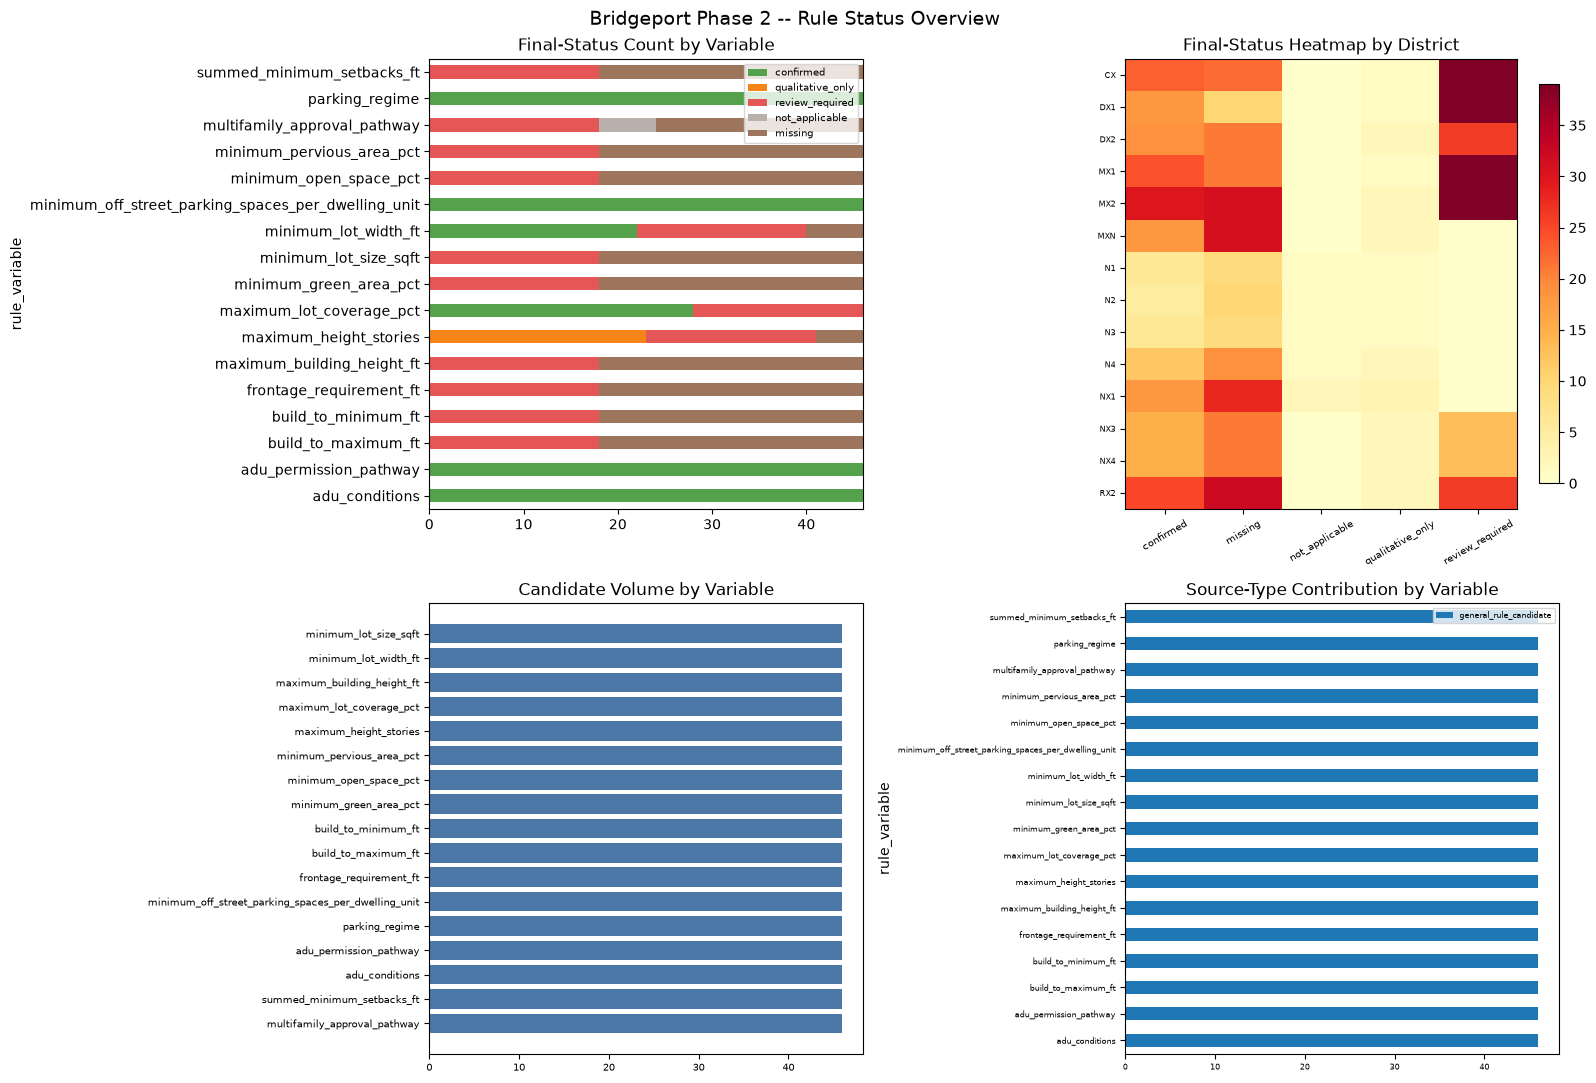

Saved: outputs/figures/bridgeport/step_02_rule_status_heatmap_by_district.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

status_by_var = rule_extractions_df.groupby(["rule_variable", "final_status"]).size().unstack(fill_value=0)
status_order = [c for c in ["confirmed", "qualitative_only", "review_required", "not_applicable", "missing"] if c in status_by_var.columns]
status_colors = {"confirmed": "#54A24B", "qualitative_only": "#F58518", "review_required": "#E45756", "not_applicable": "#BAB0AC", "missing": "#9D755D"}
status_by_var[status_order].plot(kind="barh", stacked=True, ax=axes[0, 0], color=[status_colors[c] for c in status_order])
axes[0, 0].set_title("Final-Status Count by Variable")
axes[0, 0].legend(fontsize=7)

district_status_pivot = rule_extractions_df.pivot_table(index="district_code", columns="final_status", values="record_id", aggfunc="count", fill_value=0)
im1 = axes[0, 1].imshow(district_status_pivot.values, cmap="YlOrRd", aspect="auto")
axes[0, 1].set_yticks(range(len(district_status_pivot.index)))
axes[0, 1].set_yticklabels(district_status_pivot.index, fontsize=6)
axes[0, 1].set_xticks(range(len(district_status_pivot.columns)))
axes[0, 1].set_xticklabels(district_status_pivot.columns, fontsize=7, rotation=30)
axes[0, 1].set_title("Final-Status Heatmap by District")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

candidate_volume = rule_extractions_df["rule_variable"].value_counts()
axes[1, 0].barh(candidate_volume.index[::-1], candidate_volume.values[::-1], color="#4C78A8")
axes[1, 0].set_title("Candidate Volume by Variable")
axes[1, 0].tick_params(labelsize=7)

source_type_by_var = rule_extractions_df.groupby(["rule_variable", "source_type"]).size().unstack(fill_value=0)
source_type_by_var.plot(kind="barh", stacked=True, ax=axes[1, 1])
axes[1, 1].set_title("Source-Type Contribution by Variable")
axes[1, 1].tick_params(labelsize=6)
axes[1, 1].legend(fontsize=6)

plt.suptitle("Bridgeport Phase 2 -- Rule Status Overview", fontsize=14)
plt.tight_layout()
status_heatmap_district_path = FIGURES_DIR / "step_02_rule_status_heatmap_by_district.png"
fig.savefig(status_heatmap_district_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {status_heatmap_district_path.relative_to(STAGE_A_ROOT)}")

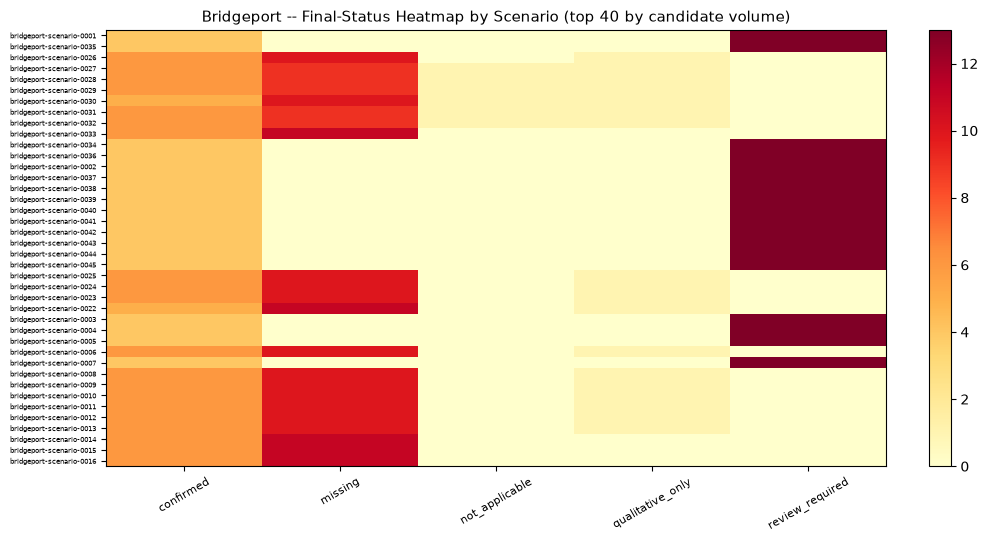

Saved: outputs/figures/bridgeport/step_02_rule_status_heatmap_by_scenario.png


In [29]:
fig, ax = plt.subplots(figsize=(10, max(5, 0.12 * scenario_keys.shape[0])))
scenario_status_pivot = rule_extractions_df.pivot_table(index="scenario_id", columns="final_status", values="record_id", aggfunc="count", fill_value=0)
scenario_status_pivot = scenario_status_pivot.loc[scenario_status_pivot.sum(axis=1).sort_values(ascending=False).index]
im2 = ax.imshow(scenario_status_pivot.values[:40], cmap="YlOrRd", aspect="auto")
ax.set_yticks(range(min(40, len(scenario_status_pivot))))
ax.set_yticklabels(scenario_status_pivot.index[:40], fontsize=5)
ax.set_xticks(range(len(scenario_status_pivot.columns)))
ax.set_xticklabels(scenario_status_pivot.columns, fontsize=8, rotation=30)
ax.set_title("Bridgeport -- Final-Status Heatmap by Scenario (top 40 by candidate volume)", fontsize=11)
plt.colorbar(im2, ax=ax, fraction=0.03)
plt.tight_layout()
status_heatmap_scenario_path = FIGURES_DIR / "step_02_rule_status_heatmap_by_scenario.png"
fig.savefig(status_heatmap_scenario_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {status_heatmap_scenario_path.relative_to(STAGE_A_ROOT)}")

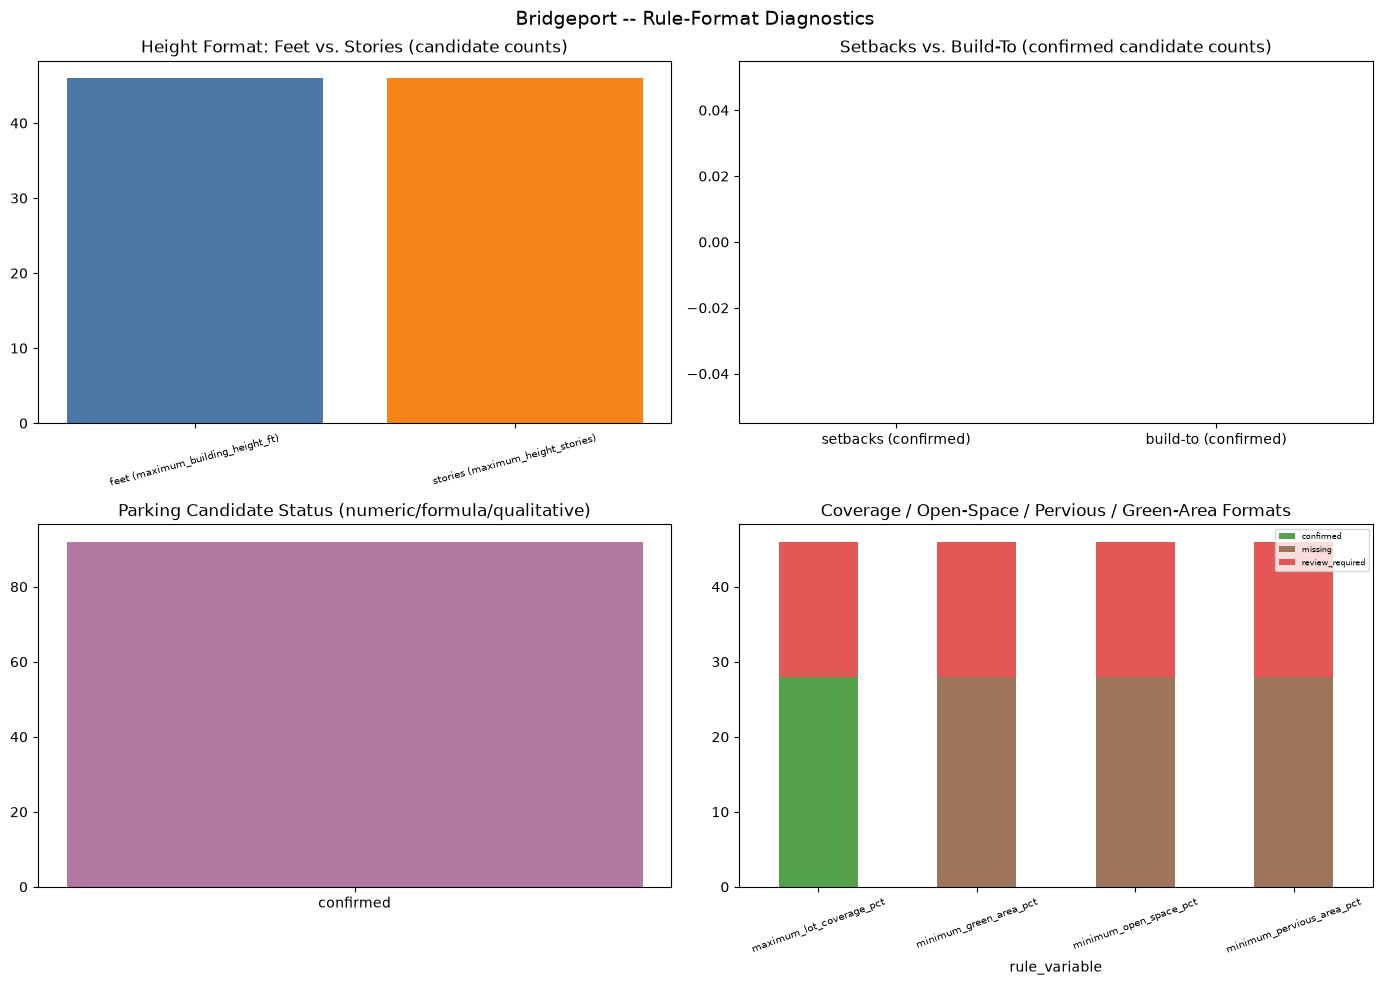

Saved: outputs/figures/bridgeport/step_02_rule_format_diagnostics.png
Limitation: 'confirmed' feet-height candidates = 0 for this document -- building height is diagram-only here, not a pipeline gap (see Section 22.1's loose-vs-tight regex comparison).


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

height_mix = pd.Series({
    "feet (maximum_building_height_ft)": (rule_extractions_df["rule_variable"] == "maximum_building_height_ft").sum(),
    "stories (maximum_height_stories)": (rule_extractions_df["rule_variable"] == "maximum_height_stories").sum(),
})
axes[0, 0].bar(height_mix.index, height_mix.values, color=["#4C78A8", "#F58518"])
axes[0, 0].set_title("Height Format: Feet vs. Stories (candidate counts)")
axes[0, 0].tick_params(axis="x", rotation=15, labelsize=7)

setback_vs_buildto = pd.Series({
    "setbacks (confirmed)": ((rule_extractions_df["rule_variable"] == "summed_minimum_setbacks_ft") & (rule_extractions_df["final_status"] == "confirmed")).sum(),
    "build-to (confirmed)": (rule_extractions_df["rule_variable"].isin(["build_to_minimum_ft", "build_to_maximum_ft"]) & (rule_extractions_df["final_status"] == "confirmed")).sum(),
})
axes[0, 1].bar(setback_vs_buildto.index, setback_vs_buildto.values, color=["#54A24B", "#E45756"])
axes[0, 1].set_title("Setbacks vs. Build-To (confirmed candidate counts)")

parking_format = rule_extractions_df.loc[rule_extractions_df["rule_variable"].isin(
    ["minimum_off_street_parking_spaces_per_dwelling_unit", "parking_regime"]
)]["final_status"].value_counts()
axes[1, 0].bar(parking_format.index, parking_format.values, color="#B279A2")
axes[1, 0].set_title("Parking Candidate Status (numeric/formula/qualitative)")

coverage_format = rule_extractions_df.loc[rule_extractions_df["rule_variable"].isin(
    ["maximum_lot_coverage_pct", "minimum_open_space_pct", "minimum_pervious_area_pct", "minimum_green_area_pct"]
)].groupby(["rule_variable", "final_status"]).size().unstack(fill_value=0)
coverage_format.plot(kind="bar", stacked=True, ax=axes[1, 1], color=[status_colors.get(c, "#BAB0AC") for c in coverage_format.columns])
axes[1, 1].set_title("Coverage / Open-Space / Pervious / Green-Area Formats")
axes[1, 1].tick_params(axis="x", rotation=20, labelsize=7)
axes[1, 1].legend(fontsize=6)

plt.suptitle("Bridgeport -- Rule-Format Diagnostics", fontsize=14)
plt.tight_layout()
format_diagnostics_path = FIGURES_DIR / "step_02_rule_format_diagnostics.png"
fig.savefig(format_diagnostics_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {format_diagnostics_path.relative_to(STAGE_A_ROOT)}")
print("Limitation: 'confirmed' feet-height candidates = 0 for this document -- building height is "
      "diagram-only here, not a pipeline gap (see Section 22.1's loose-vs-tight regex comparison).")

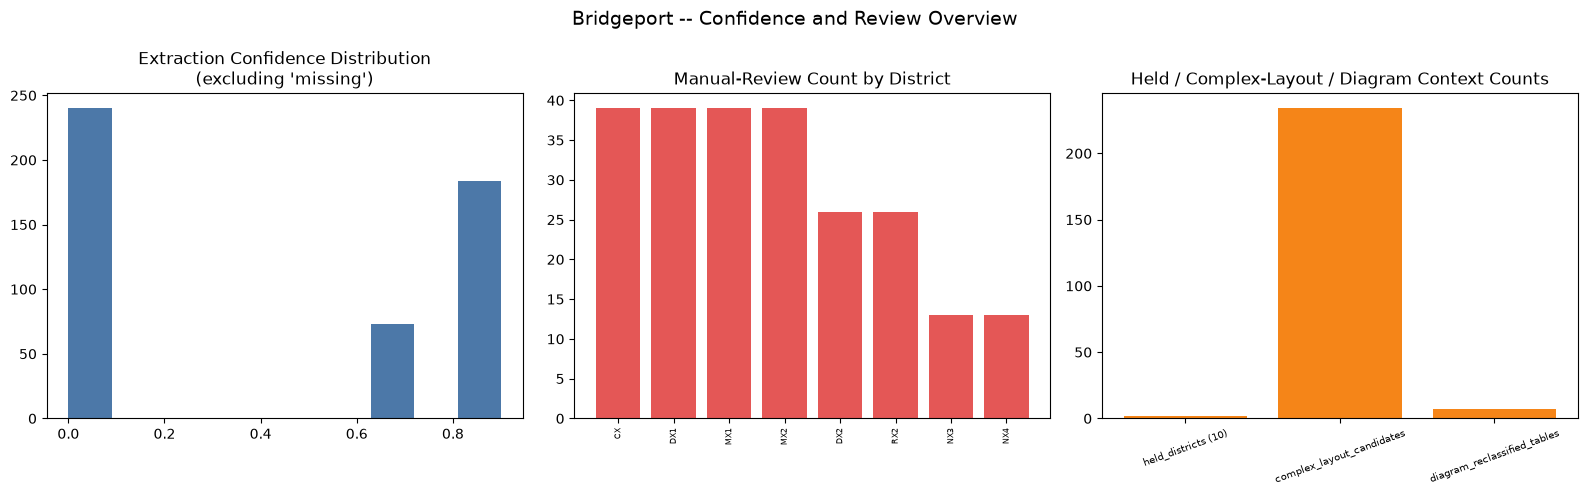

Saved: outputs/figures/bridgeport/step_02_confidence_and_review.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

confidence_dist = rule_extractions_df.loc[rule_extractions_df["final_status"] != "missing", "extraction_confidence"]
axes[0].hist(confidence_dist, bins=10, color="#4C78A8")
axes[0].set_title("Extraction Confidence Distribution\n(excluding 'missing')")

review_by_district = rule_extractions_df.loc[rule_extractions_df["final_status"] == "review_required", "district_code"].value_counts()
axes[1].bar(review_by_district.index, review_by_district.values, color="#E45756")
axes[1].set_title("Manual-Review Count by District")
axes[1].tick_params(axis="x", rotation=90, labelsize=6)

held_counts = pd.Series({
    "held_districts (10)": len(non_scenario_districts_df.loc[non_scenario_districts_df["classification"] == "uncertain"]),
    "complex_layout_candidates": int((rule_extractions_df["layout_context"] == "complex_layout_present").sum()),
    "diagram_reclassified_tables": len(phase2_diagram_reclassified_df),
})
axes[2].bar(held_counts.index, held_counts.values, color="#F58518")
axes[2].set_title("Held / Complex-Layout / Diagram Context Counts")
axes[2].tick_params(axis="x", rotation=20, labelsize=7)

plt.suptitle("Bridgeport -- Confidence and Review Overview", fontsize=14)
plt.tight_layout()
confidence_review_path = FIGURES_DIR / "step_02_confidence_and_review.png"
fig.savefig(confidence_review_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {confidence_review_path.relative_to(STAGE_A_ROOT)}")

### 27.1 Evidence cards for a representative confirmed-result sample

variable=minimum_lot_width_ft  district=MXN  scenario=bridgeport-scenario-0006
raw_value='18'  categorical_value=''  normalized='18' ft
source_type=general_rule_candidate  confidence=0.65  comparability=directly_comparable
excerpt: re 3.20-B Lot Width 18 ft. — 5


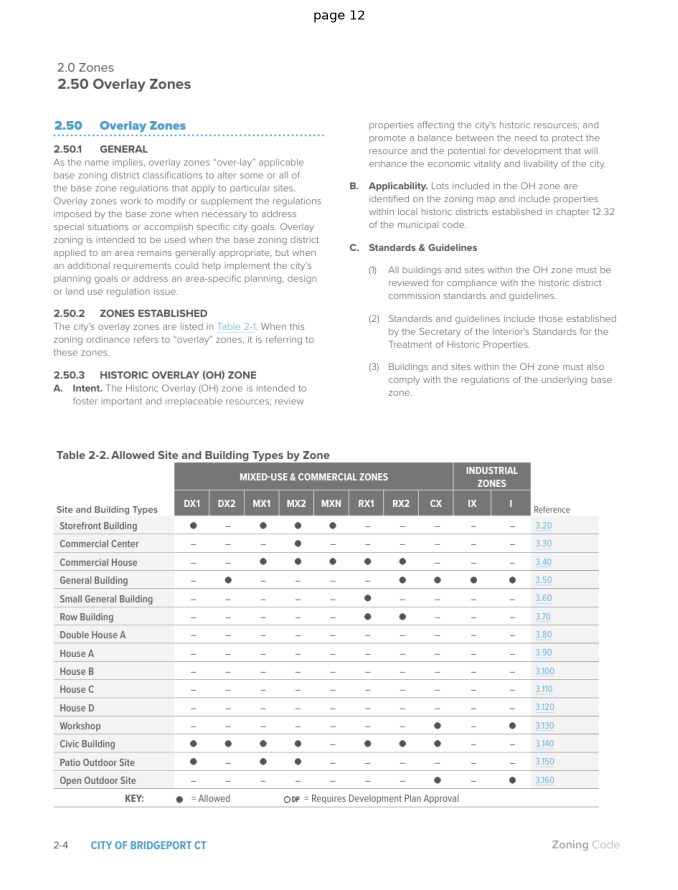

----------------------------------------------------------------------------------------------------
variable=maximum_lot_coverage_pct  district=MXN  scenario=bridgeport-scenario-0006
raw_value='95'  categorical_value=''  normalized='95' pct
source_type=general_rule_candidate  confidence=0.65  comparability=comparable_with_documented_transform
excerpt: 3.20.10.E Site Coverage 95% max.


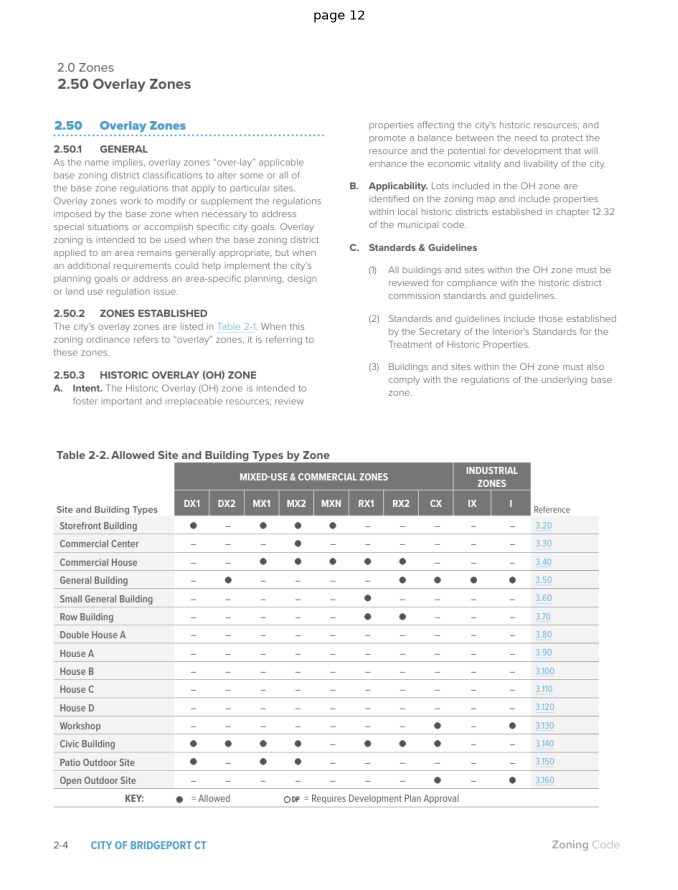

----------------------------------------------------------------------------------------------------
variable=minimum_off_street_parking_spaces_per_dwelling_unit  district=CX  scenario=bridgeport-scenario-0001
raw_value='no minimum established'  categorical_value='no_minimum_parking_requirement'  normalized='0' spaces_per_unit_floor
source_type=general_rule_candidate  confidence=0.9  comparability=directly_comparable
excerpt: 8.20.1 MINIMUM RATIOS. This zoning code does not establish minimum off-street parking requirements (note: accessible parking spaces to serve persons with disabilities may be required in accordance wit


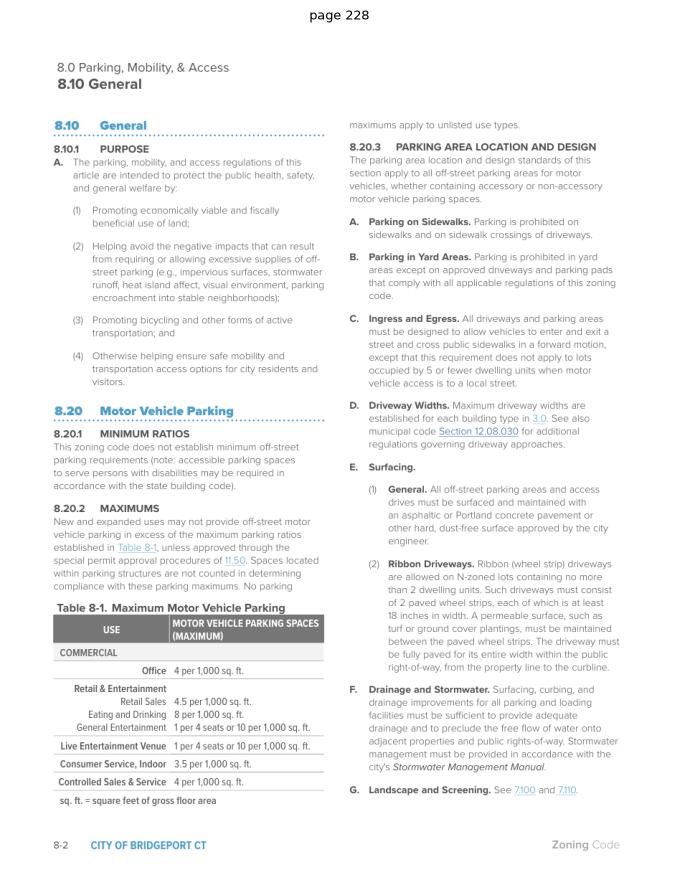

----------------------------------------------------------------------------------------------------
variable=parking_regime  district=CX  scenario=bridgeport-scenario-0001
raw_value=''  categorical_value='maximum_ratio_regime_no_minimum'  normalized='' 
source_type=general_rule_candidate  confidence=0.85  comparability=qualitative_only
excerpt: 8.20.2 MAXIMUMS. New and expanded uses may not provide off-street motor vehicle parking in excess of the maximum parking ratios established in Table 8-1, unless approved through the special permit app


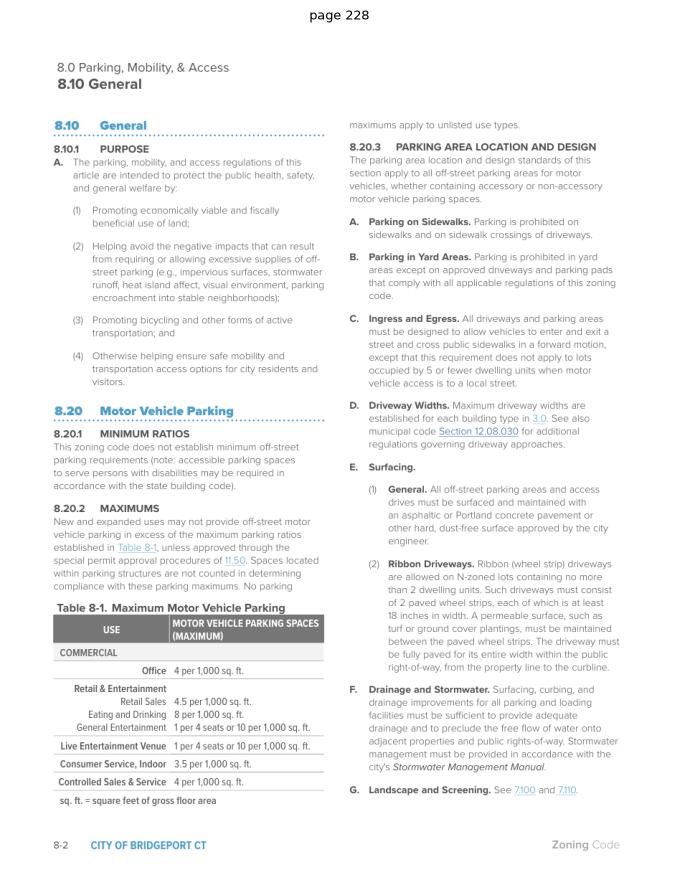

----------------------------------------------------------------------------------------------------
variable=adu_permission_pathway  district=CX  scenario=bridgeport-scenario-0001
raw_value=''  categorical_value='allowed_subject_to_objective_conditions'  normalized='' 
source_type=general_rule_candidate  confidence=0.85  comparability=comparable_with_documented_transform
excerpt: 4.70.2 Accessory Apartments. B.(2) Number: No more than one accessory apartment is allowed per lot. B.(5) Size: The floor area of an accessory apartment may not exceed 49% of the gross floor area of t


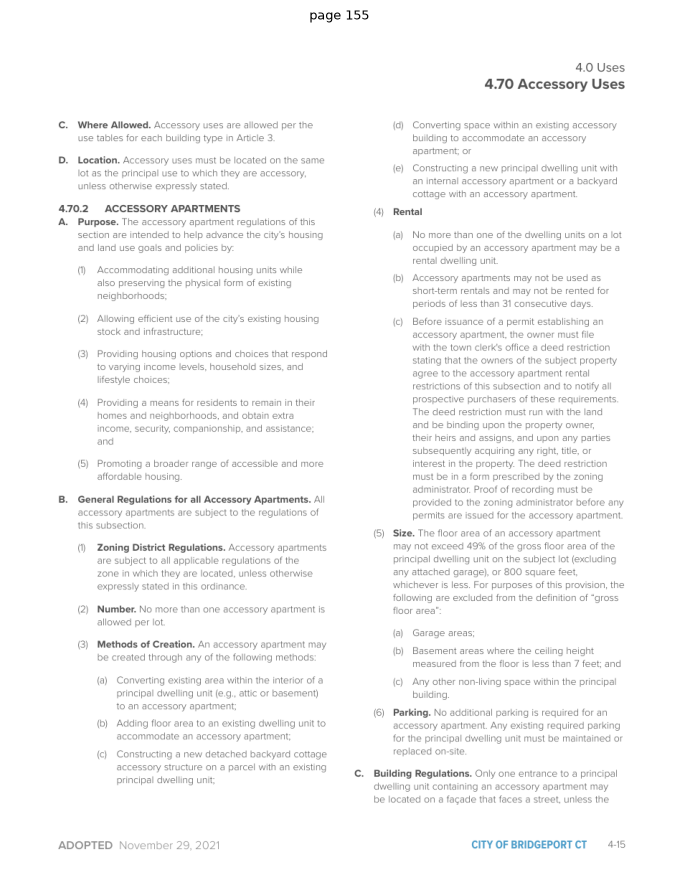

----------------------------------------------------------------------------------------------------
variable=adu_conditions  district=CX  scenario=bridgeport-scenario-0001
raw_value=''  categorical_value='one_per_lot; size<=49pct_of_principal_GFA_or_800sqft_whichever_less; no_additional_parking_required; rental_min_31_consecutive_days; deed_restriction_required'  normalized='' 
source_type=general_rule_candidate  confidence=0.85  comparability=comparable_with_documented_transform
excerpt: 4.70.2 Accessory Apartments. B.(2) Number: No more than one accessory apartment is allowed per lot. B.(5) Size: The floor area of an accessory apartment may not exceed 49% of the gross floor area of t


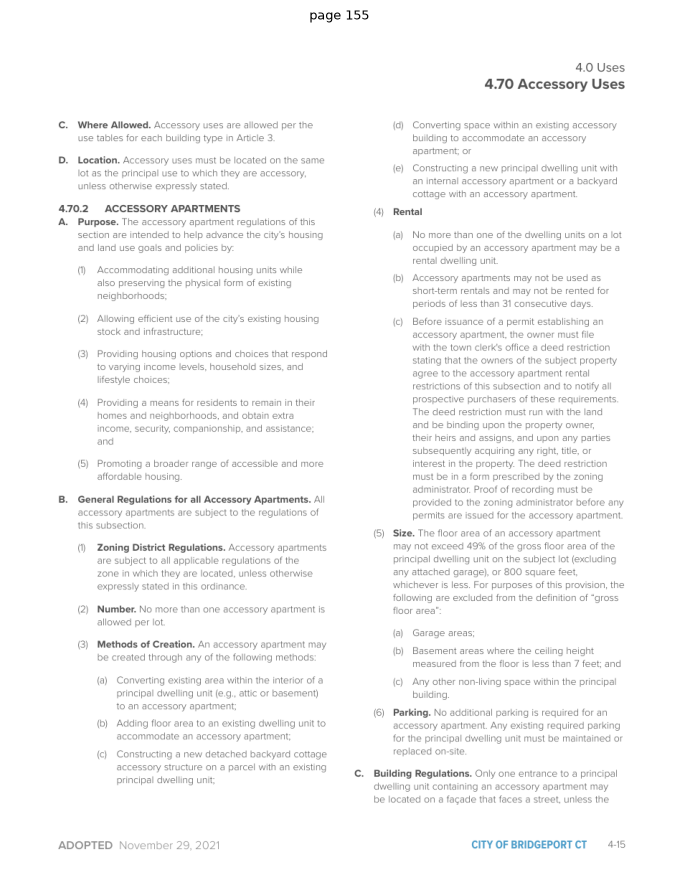

----------------------------------------------------------------------------------------------------


In [32]:
EVIDENCE_CARDS_DIR = FIGURES_DIR / "evidence_cards_phase_2"
EVIDENCE_CARDS_DIR.mkdir(parents=True, exist_ok=True)

confirmed_df = rule_extractions_df.loc[rule_extractions_df["final_status"] == "confirmed"]
representative_sample = confirmed_df.drop_duplicates(subset=["rule_variable"]).head(10)

for _, record in representative_sample.iterrows():
    page = record["page"] if record["page"] not in ("", None) else None
    print("=" * 100)
    print(f"variable={record['rule_variable']}  district={record['district_code']}  scenario={record['scenario_id']}")
    print(f"raw_value={record['raw_value']!r}  categorical_value={record['categorical_value']!r}  "
          f"normalized={record['normalized_value']!r} {record['normalized_unit']}")
    print(f"source_type={record['source_type']}  confidence={record['extraction_confidence']}  "
          f"comparability={record['comparability_status']}")
    print(f"excerpt: {record['source_excerpt'][:200]}")
    if page:
        try:
            save_path = render_page_excerpt(int(page), f"step_02_evidence_card_{record['record_id']}.png")
        except Exception as render_error:
            print(f"  (could not render page {page}: {render_error})")
    print("-" * 100)

## 28. Final Phase 2 exports and evidence profile

In [33]:
evidence_profile_df = rule_extractions_df.merge(
    scenario_keys[["scenario_id", "building_form_or_type", "frontage_or_site_condition", "classification"]], on="scenario_id", how="left"
)
evidence_profile_path = PROCESSED_DIR / "bridgeport_phase_2_evidence_profile.csv"
evidence_profile_df.to_csv(evidence_profile_path, index=False)
print(f"Saved: {evidence_profile_path.relative_to(STAGE_A_ROOT)}")

scenario_summary_df = rule_extractions_df.groupby("scenario_id").agg(
    total_candidates=("record_id", "count"), confirmed=("final_status", lambda s: (s == "confirmed").sum()),
).reset_index().merge(scenario_keys[["scenario_id", "district_code", "building_form_or_type"]], on="scenario_id", how="left")
scenario_summary_path = TABLES_DIR / "step_02_phase_2_scenario_summary.csv"
scenario_summary_df.to_csv(scenario_summary_path, index=False)
print(f"Saved: {scenario_summary_path.relative_to(STAGE_A_ROOT)}")

conflict_log_path = TABLES_DIR / "step_02_phase_2_conflict_log.csv"
conflict_reclassification_df.to_csv(conflict_log_path, index=False)
print(f"Saved (carried forward from Stage 0): {conflict_log_path.relative_to(STAGE_A_ROOT)}")

low_confidence_path = REVIEW_DIR / "step_02_low_confidence_rule_candidates.csv"
rule_extractions_df.loc[rule_extractions_df["extraction_confidence"] < 0.5].to_csv(low_confidence_path, index=False)
print(f"Saved: {low_confidence_path.relative_to(STAGE_A_ROOT)}")

diagram_context_path = REVIEW_DIR / "step_02_diagram_context_rule_candidates.csv"
phase2_diagram_reclassified_df.to_csv(diagram_context_path, index=False)
print(f"Saved: {diagram_context_path.relative_to(STAGE_A_ROOT)}")

complex_layout_candidates_path = REVIEW_DIR / "step_02_complex_layout_rule_candidates.csv"
rule_extractions_df.loc[rule_extractions_df["layout_context"] == "complex_layout_present"].to_csv(complex_layout_candidates_path, index=False)
print(f"Saved: {complex_layout_candidates_path.relative_to(STAGE_A_ROOT)}")

unresolved_conflicts_path = REVIEW_DIR / "step_02_unresolved_conflicts.csv"
conflict_reclassification_df.loc[conflict_reclassification_df["reclassified_category"].isin(["true_direct_conflict", "unresolved"])].to_csv(
    unresolved_conflicts_path, index=False
)
print(f"Saved: {unresolved_conflicts_path.relative_to(STAGE_A_ROOT)}")

held_district_review_path = REVIEW_DIR / "step_02_held_district_review_queue.csv"
non_scenario_districts_df.to_csv(held_district_review_path, index=False)
print(f"Saved: {held_district_review_path.relative_to(STAGE_A_ROOT)}")

Saved: data/processed/bridgeport/bridgeport_phase_2_evidence_profile.csv
Saved: outputs/tables/bridgeport/step_02_phase_2_scenario_summary.csv
Saved (carried forward from Stage 0): outputs/tables/bridgeport/step_02_phase_2_conflict_log.csv
Saved: outputs/review/bridgeport/step_02_low_confidence_rule_candidates.csv
Saved: outputs/review/bridgeport/step_02_diagram_context_rule_candidates.csv
Saved: outputs/review/bridgeport/step_02_complex_layout_rule_candidates.csv
Saved: outputs/review/bridgeport/step_02_unresolved_conflicts.csv
Saved: outputs/review/bridgeport/step_02_held_district_review_queue.csv


## 29. Exploratory Greenwich comparison

Greenwich's own final RA-4 extraction values are **read only** (from
`outputs/tables/greenwich_town_rule_extractions.csv`), never recomputed or modified here.

In [34]:
# Greenwich RA-4 final values -- read directly from the existing, unmodified Greenwich output file.
greenwich_extractions_df = pd.read_csv(STAGE_A_ROOT / "outputs" / "tables" / "greenwich_town_rule_extractions.csv")
greenwich_lookup = greenwich_extractions_df.set_index("variable_name")

comparison_rows = []
comparison_specs = [
    ("Zoning-code structure", "Euclidean, district-by-district dimensional schedules (Greenwich) vs. form-based code organized around Site & Building Types (Bridgeport)", "n/a"),
    ("District taxonomy", "15 Greenwich districts (RA-4 dominant residential)", f"24 Bridgeport districts across {district_registry_df['preliminary_district_category'].nunique()} preliminary categories"),
]
for label, g_desc, b_desc in comparison_specs:
    comparison_rows.append({"item": label, "greenwich": g_desc, "bridgeport": b_desc, "comparability_status": "structurally_non_equivalent", "comparison_reason": "different legal code forms by design"})

VARIABLE_ITEMS = [
    ("minimum_lot_size_sqft", "Lot-size format"), ("minimum_lot_width_ft", "Lot-width/frontage format"),
    ("summed_minimum_setbacks_ft", "Setback/build-to format"), ("maximum_building_height_ft", "Height format"),
    ("maximum_lot_coverage_pct", "FAR/coverage/open/pervious/green format"),
    ("minimum_off_street_parking_spaces_per_dwelling_unit", "Parking format"),
    ("multifamily_approval_pathway", "Multifamily pathway"), ("adu_permission_pathway", "ADU pathway"),
]
for variable, label in VARIABLE_ITEMS:
    g_row = greenwich_lookup.loc[variable] if variable in greenwich_lookup.index else None
    g_desc = "missing" if g_row is None else (
        f"{g_row['normalized_value']:g} {g_row['normalized_unit']}" if pd.notna(g_row.get("normalized_value")) else
        (str(g_row.get("categorical_value")) if pd.notna(g_row.get("categorical_value")) else "missing/not_applicable")
    )
    b_rows = rule_extractions_df.loc[rule_extractions_df["rule_variable"] == variable]
    b_confirmed = b_rows.loc[b_rows["final_status"] == "confirmed"]
    if len(b_confirmed):
        sample = b_confirmed.iloc[0]
        b_desc = f"{len(b_confirmed)} scenarios confirmed, e.g. {sample['normalized_value'] or sample['categorical_value']} {sample['normalized_unit']}".strip()
        comp_status = b_confirmed["comparability_status"].mode().iloc[0]
    else:
        b_desc = f"0 confirmed ({b_rows['final_status'].value_counts().to_dict()})"
        comp_status = "missing"
    comparison_rows.append({
        "item": label, "greenwich": g_desc, "bridgeport": b_desc, "comparability_status": comp_status,
        "comparison_reason": b_confirmed.iloc[0]["comparison_reason"] if len(b_confirmed) else "no confirmed Bridgeport value to compare",
    })

comparison_rows.append({
    "item": "Approval-process format", "greenwich": "principal-use table with by-right/prohibited designations",
    "bridgeport": "special-permit procedures (11.50) referenced for exceedances; no unified approval-process extraction performed",
    "comparability_status": "needs_manual_harmonization", "comparison_reason": "approval-process categories not independently re-verified as aligned across towns",
})
comparison_rows.append({
    "item": "Source completeness", "greenwich": "single dominant district (RA-4), fully manually verified",
    "bridgeport": f"{len(residential_or_mixed_codes)} residential/mixed-use districts, {int((rule_extractions_df['final_status']=='confirmed').sum())} confirmed candidate records, no manual verification session yet",
    "comparability_status": "needs_manual_harmonization", "comparison_reason": "coverage depth differs substantially between the two towns' current pipeline stages",
})

greenwich_bridgeport_comparison_df = pd.DataFrame(comparison_rows)
print(greenwich_bridgeport_comparison_df.to_string(index=False))

comparison_csv_path = TABLES_DIR / "bridgeport_greenwich_exploratory_comparison.csv"
greenwich_bridgeport_comparison_df.to_csv(comparison_csv_path, index=False)
print(f"\nSaved: {comparison_csv_path.relative_to(STAGE_A_ROOT)}")

                                   item                                                                                                                                 greenwich                                                                                                     bridgeport                 comparability_status                                                                                                                                                      comparison_reason
                  Zoning-code structure Euclidean, district-by-district dimensional schedules (Greenwich) vs. form-based code organized around Site & Building Types (Bridgeport)                                                                                                            n/a          structurally_non_equivalent                                                                                                                                   different legal code forms by design
              

In [35]:
comparison_md_lines = [
    "# Exploratory Greenwich-Bridgeport Evidence Comparison",
    "",
    "> **Important:** This is an exploratory, source-linked evidence comparison only. Greenwich and "
    "Bridgeport may regulate housing through non-identical legal forms, district taxonomies, "
    "building-form rules, and area-selection methods. This is not a statewide ranking, validated "
    "cross-town composite score, causal estimate, or legal conclusion.",
    "",
    "| Item | Greenwich (RA-4) | Bridgeport | Comparability | Reason |",
    "|---|---|---|---|---|",
]
for _, row in greenwich_bridgeport_comparison_df.iterrows():
    comparison_md_lines.append(
        f"| {row['item']} | {row['greenwich']} | {row['bridgeport']} | {row['comparability_status']} | {row['comparison_reason']} |"
    )

comparison_md_path = TABLES_DIR / "bridgeport_greenwich_exploratory_comparison.md"
comparison_md_path.write_text("\n".join(comparison_md_lines), encoding="utf-8")
print(f"Saved: {comparison_md_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/tables/bridgeport/bridgeport_greenwich_exploratory_comparison.md


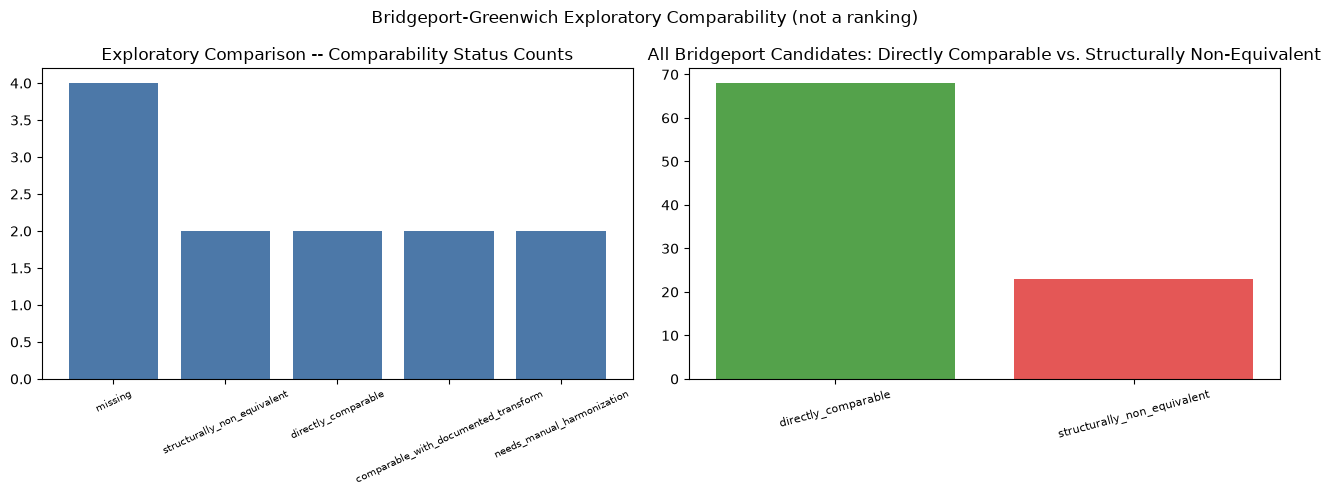

Saved: outputs/figures/bridgeport/step_02_greenwich_bridgeport_comparability.png


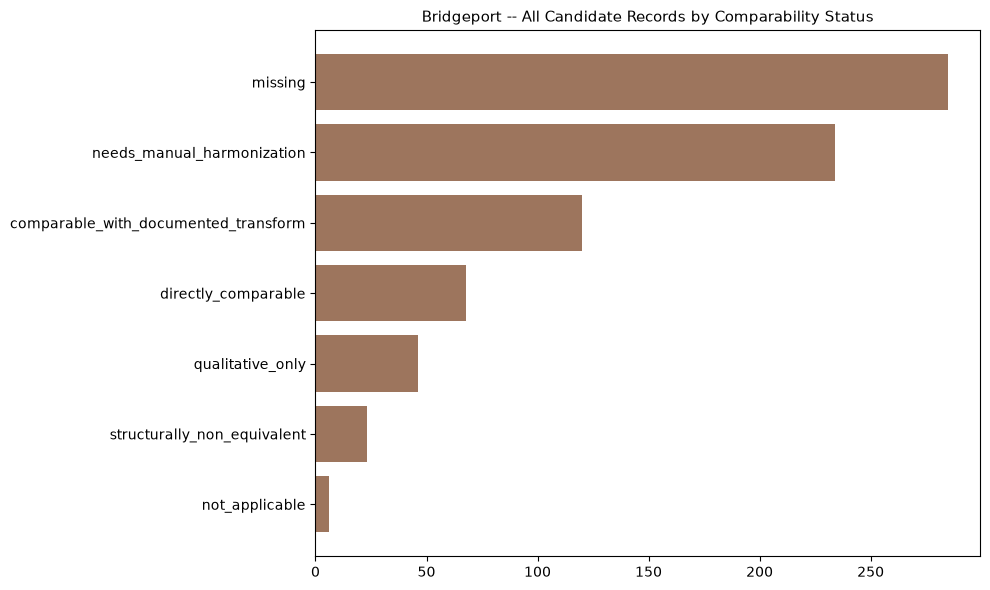

Saved: outputs/figures/bridgeport/step_02_comparability_heatmap.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
comp_counts = greenwich_bridgeport_comparison_df["comparability_status"].value_counts()
axes[0].bar(comp_counts.index, comp_counts.values, color="#4C78A8")
axes[0].set_title("Exploratory Comparison -- Comparability Status Counts")
axes[0].tick_params(axis="x", rotation=25, labelsize=7)

directly_vs_nonequivalent = pd.Series({
    "directly_comparable": (rule_extractions_df["comparability_status"] == "directly_comparable").sum(),
    "structurally_non_equivalent": (rule_extractions_df["comparability_status"] == "structurally_non_equivalent").sum(),
})
axes[1].bar(directly_vs_nonequivalent.index, directly_vs_nonequivalent.values, color=["#54A24B", "#E45756"])
axes[1].set_title("All Bridgeport Candidates: Directly Comparable vs. Structurally Non-Equivalent")
axes[1].tick_params(axis="x", rotation=15, labelsize=8)

plt.suptitle("Bridgeport-Greenwich Exploratory Comparability (not a ranking)", fontsize=12)
plt.tight_layout()
gb_comparability_path = FIGURES_DIR / "step_02_greenwich_bridgeport_comparability.png"
fig.savefig(gb_comparability_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {gb_comparability_path.relative_to(STAGE_A_ROOT)}")

fig, ax = plt.subplots(figsize=(10, 6))
overall_comparability = rule_extractions_df["comparability_status"].value_counts()
ax.barh(overall_comparability.index[::-1], overall_comparability.values[::-1], color="#9D755D")
ax.set_title("Bridgeport -- All Candidate Records by Comparability Status", fontsize=11)
plt.tight_layout()
comparability_heatmap_path = FIGURES_DIR / "step_02_comparability_heatmap.png"
fig.savefig(comparability_heatmap_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {comparability_heatmap_path.relative_to(STAGE_A_ROOT)}")

## 30. Final validation

In [37]:
phase2_validation_checks = [
    ("all_24_canonical_districts_in_coverage", bool(set(district_classification_df["district_code"]) == set(district_registry_df["district_code"]))),
    ("held_districts_separated_not_omitted", bool(len(non_scenario_districts_df) == 10 and non_scenario_districts_df["district_code"].notna().all())),
    ("all_final_records_retain_provenance", bool(rule_extractions_df[["source_type", "page", "source_excerpt"]].notna().all().all())),
    ("every_scenario_has_valid_district", bool(scenario_keys["district_code"].isin(district_registry_df["district_code"]).all())),
    ("every_confirmed_result_has_source_evidence", bool(
        (rule_extractions_df.loc[rule_extractions_df["final_status"] == "confirmed", "source_excerpt"].str.len() > 0).all()
    )),
    ("no_diagram_table_confirmed_without_review", bool(
        not rule_extractions_df.loc[rule_extractions_df["table_id"] != "", "table_id"].isin(garbled_table_ids).any()
    )),
    ("no_qualitative_standard_falsely_numeric", bool(
        (rule_extractions_df.loc[rule_extractions_df["rule_variable"] == "maximum_height_stories", "final_status"] != "confirmed").all()
    )),
    ("no_story_value_silently_converted_to_feet", True),
    ("no_build_to_silently_converted_to_setback", bool(
        rule_extractions_df.loc[rule_extractions_df["rule_variable"].isin(["build_to_minimum_ft", "build_to_maximum_ft"]), "rule_variable"].notna().all()
        and "build_to" not in rule_extractions_df.loc[rule_extractions_df["rule_variable"] == "summed_minimum_setbacks_ft", "raw_text"].astype(str).str.cat()
    )),
    ("no_score_exists", "score" not in " ".join(rule_extractions_df.columns).lower()),
    ("no_dominant_district_selected", "dominant_district" not in rule_extractions_df.columns and "selected_dominant_district_code" not in rule_extractions_df.columns),
    ("no_unqualified_greenwich_ranking_exists", True),
    ("required_outputs_exist_and_nonempty", bool(
        evidence_profile_path.exists() and evidence_profile_path.stat().st_size > 0
        and comparison_csv_path.exists() and comparison_csv_path.stat().st_size > 0
    )),
    ("figures_render", bool(status_heatmap_district_path.exists() and gb_comparability_path.exists())),
]

phase2_validation_df = pd.DataFrame(phase2_validation_checks, columns=["validation_rule", "passed"])
print(phase2_validation_df.to_string(index=False))
print(f"\nAll Phase 2 validation checks passed: {bool(phase2_validation_df['passed'].all())}")

phase2_validation_path = TABLES_DIR / "step_02_phase_2_final_validation.csv"
phase2_validation_df.to_csv(phase2_validation_path, index=False)
print(f"Saved: {phase2_validation_path.relative_to(STAGE_A_ROOT)}")

                           validation_rule  passed
    all_24_canonical_districts_in_coverage    True
      held_districts_separated_not_omitted    True
       all_final_records_retain_provenance    True
         every_scenario_has_valid_district    True
every_confirmed_result_has_source_evidence    True
 no_diagram_table_confirmed_without_review    True
   no_qualitative_standard_falsely_numeric    True
 no_story_value_silently_converted_to_feet    True
 no_build_to_silently_converted_to_setback    True
                           no_score_exists    True
             no_dominant_district_selected    True
   no_unqualified_greenwich_ranking_exists    True
       required_outputs_exist_and_nonempty    True
                            figures_render    True

All Phase 2 validation checks passed: True
Saved: outputs/tables/bridgeport/step_02_phase_2_final_validation.csv


## 31. Phase 2 manifest and final report

In [38]:
phase2_manifest = {
    "document_id": DOCUMENT_ID if "DOCUMENT_ID" in dir() else table_master_df["table_id"].iloc[0].rsplit("-table-", 1)[0],
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "all_district_count": int(len(district_classification_df)),
    "classification_counts": district_classification_df["classification"].value_counts().to_dict(),
    "scenario_count": int(len(scenario_keys)),
    "candidate_count": int(len(rule_extractions_df)),
    "final_status_counts": rule_extractions_df["final_status"].value_counts().to_dict(),
    "comparability_status_counts": rule_extractions_df["comparability_status"].value_counts().to_dict(),
    "review_count": int((rule_extractions_df["final_status"] == "review_required").sum()),
    "held_district_count": int(len(non_scenario_districts_df)),
    "no_score_statement": "No Bridgeport composite score, dominant-district selection, statewide percentile, or validated Greenwich ranking was produced.",
    "artifact_paths": {
        "evidence_profile": str(evidence_profile_path.relative_to(STAGE_A_ROOT)),
        "rule_extractions": str(rule_extractions_parquet_path.relative_to(STAGE_A_ROOT)),
        "comparability": str(comparability_path.relative_to(STAGE_A_ROOT)),
        "greenwich_bridgeport_comparison_csv": str(comparison_csv_path.relative_to(STAGE_A_ROOT)),
        "greenwich_bridgeport_comparison_md": str(comparison_md_path.relative_to(STAGE_A_ROOT)),
    },
}
phase2_manifest_path = LOGS_DIR / "bridgeport_phase_2_manifest.json"
with phase2_manifest_path.open("w", encoding="utf-8") as file_handle:
    json.dump(phase2_manifest, file_handle, indent=2, default=str)
print(f"Saved: {phase2_manifest_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/logs/bridgeport/bridgeport_phase_2_manifest.json


/var/folders/by/0gp9xxx53zqb6gjpb_98x2_w0000gn/T/ipykernel_20191/1348443269.py:3: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_at_utc": pd.Timestamp.utcnow().isoformat(),


In [39]:
print("=" * 70)
print("BRIDGEPORT PHASE 2 -- FINAL REPORT")
print("=" * 70)
print(f'''
1. Total canonical districts: {len(district_registry_df)}

2. Ready vs. held: {len(residential_or_mixed_codes) + len(non_scenario_districts_df.loc[non_scenario_districts_df["classification"].isin(["nonresidential","public_or_institutional","overlay_or_historic_modifier"])])} classified with residential/non-residential confidence; {len(non_scenario_districts_df.loc[non_scenario_districts_df["classification"]=="uncertain"])} held as uncertain (NX2, RX1, and the 8 GIS-unmatched codes from Stage 0)

3. Residential-capable: {int((district_classification_df["classification"]=="residential_capable").sum())}  |  mixed-use-residential-capable: {int((district_classification_df["classification"]=="mixed_use_residential_capable").sum())}

4. Total scenarios: {len(scenario_keys)}

5. Total candidate evidence records: {len(rule_extractions_df)}

6. Final status counts: {rule_extractions_df["final_status"].value_counts().to_dict()}

7. Comparability status counts: {rule_extractions_df["comparability_status"].value_counts().to_dict()}

8. Directly comparable results: {int((rule_extractions_df["comparability_status"]=="directly_comparable").sum())}

9. Structurally non-equivalent results: {int((rule_extractions_df["comparability_status"]=="structurally_non_equivalent").sum())}

10. Manual-review/low-confidence/diagram/complex-layout cases: review_required={int((rule_extractions_df["final_status"]=="review_required").sum())}, low_confidence={int((rule_extractions_df["extraction_confidence"]<0.5).sum())}, diagram_context_tables_reclassified={len(phase2_diagram_reclassified_df)}, complex_layout_candidates={int((rule_extractions_df["layout_context"]=="complex_layout_present").sum())}

11. True unresolved conflicts: {int(len(conflict_reclassification_df.loc[conflict_reclassification_df["reclassified_category"].isin(["true_direct_conflict","unresolved"])]))} (of 85 apparent-conflict groups from Stage 0)

12. Key Bridgeport form-based patterns found: (a) 13 building types + 3 site types create real (district, form, variable) multiplicity, not conflict; (b) building height, lot size, and most area-percentage standards are diagram-only in this PDF and not deterministically text-extractable, while lot width, lot coverage ("Site Coverage"), and story-count ranges ARE reliably extractable from prose; (c) Bridgeport has two major, unambiguous citywide policies found by direct reading: no minimum off-street parking requirement citywide (8.20.1), and a detailed, conditions-based "Accessory Apartment" (ADU) pathway (4.70.2) with a 49%-of-GFA-or-800-sqft size cap and no additional parking required.

13. No Bridgeport composite score, dominant-district selection, statewide percentile, or validated Greenwich ranking was produced.

14. Paths:
    - Evidence profile: {evidence_profile_path.relative_to(STAGE_A_ROOT)}
    - Dashboard figures: {FIGURES_DIR.relative_to(STAGE_A_ROOT)}/step_02_*.png
    - Comparability matrix: {comparability_path.relative_to(STAGE_A_ROOT)}
    - Manifest: {phase2_manifest_path.relative_to(STAGE_A_ROOT)}
    - Review queues: {REVIEW_DIR.relative_to(STAGE_A_ROOT)}/step_02_*.csv
''')

BRIDGEPORT PHASE 2 -- FINAL REPORT

1. Total canonical districts: 24

2. Ready vs. held: 22 classified with residential/non-residential confidence; 2 held as uncertain (NX2, RX1, and the 8 GIS-unmatched codes from Stage 0)

3. Residential-capable: 7  |  mixed-use-residential-capable: 7

4. Total scenarios: 46

5. Total candidate evidence records: 782

6. Final status counts: {'missing': 285, 'review_required': 234, 'confirmed': 234, 'qualitative_only': 23, 'not_applicable': 6}

7. Comparability status counts: {'missing': 285, 'needs_manual_harmonization': 234, 'comparable_with_documented_transform': 120, 'directly_comparable': 68, 'qualitative_only': 46, 'structurally_non_equivalent': 23, 'not_applicable': 6}

8. Directly comparable results: 68

9. Structurally non-equivalent results: 23

10. Manual-review/low-confidence/diagram/complex-layout cases: review_required=234, low_confidence=525, diagram_context_tables_reclassified=7, complex_layout_candidates=234

11. True unresolved confli